# BT4222 — Group 2: **Personalised Asset Advisory for Investors Using Recommendation Systems**  
**Group Members:**
*   Chen Zhuoxuan - A0282787J
*   Dannon Lee Kang Wei - A0272405L
*   Do Minh Nguyet - A0311868X
*   Kent Karsten Pangestu - A0326138E



**Phases:**
1. Data Loading, Cleaning & Feature Engineering  
2. Customer Clustering (KMeans / DBSCAN)  
3. Weighted CF + Content-based + Hybrid Recommender + Evaluation

**Datasets expected (CSV):** `asset_information.csv`, `close_prices.csv`, `customer_information.csv`, `limit_prices.csv`, `markets.csv`, `transactions.csv`.

> **Key Outputs (auto-printed):**  
> - KMeans: best **K**, silhouette score, cluster sizes  
> - Baselines (Popularity) & **Hybrid** model: **P@5/10/20, R@5/10/20, HR@5/10/20**  
> - Dual metrics (**Pref@K**, **Profit@K**, **Score@K**)  
> - Plots saved to `/outputs`


## Importing libraries


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from IPython.display import display
import os
from collections import defaultdict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.sparse import csr_matrix, issparse
from sklearn.preprocessing import normalize, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import seaborn as sns

##Mount Google Drive & Set paths

In [ ]:
# ============== Mount Google Drive & set paths ==============
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Set paths
DRIVE_FOLDER = Path('/content/drive/MyDrive/BT4222/Project Source Code')
os.chdir(DRIVE_FOLDER)
#filenames
FN_ASSET_INFORMATION = 'asset_information.csv'
FN_CLOSE_PRICES      = 'close_prices.csv'
FN_CUSTOMER_INFO     = 'customer_information.csv'
FN_LIMIT_PRICES      = 'limit_prices.csv'
FN_MARKETS           = 'markets.csv'
FN_TRANSACTIONS      = 'transactions.csv'

OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DRIVE_FOLDER =', DRIVE_FOLDER)
print('OUTPUT_DIR   =', OUTPUT_DIR.resolve())

Mounted at /content/drive
DRIVE_FOLDER = /content/drive/MyDrive/BT4222/Project Source Code
OUTPUT_DIR   = /content/drive/.shortcut-targets-by-id/14oZsuj48bGK6yYu0HLOiLJjG2DQkVJDz/BT4222/Project Source Code/outputs


In [ ]:
# ============== Sanity check: verify all CSVs exist ==============
required = [
    FN_ASSET_INFORMATION, FN_CLOSE_PRICES, FN_CUSTOMER_INFO,
    FN_LIMIT_PRICES, FN_MARKETS, FN_TRANSACTIONS
]
missing = [fn for fn in required if not (DRIVE_FOLDER / fn).exists()]
if missing:
    print('⚠ Missing files:', missing)
else:
    print('✅ Found all CSV files.')
    for fn in required:
        print('  -', (DRIVE_FOLDER / fn))


✅ Found all CSV files.
  - /content/drive/MyDrive/BT4222/Project Source Code/asset_information.csv
  - /content/drive/MyDrive/BT4222/Project Source Code/close_prices.csv
  - /content/drive/MyDrive/BT4222/Project Source Code/customer_information.csv
  - /content/drive/MyDrive/BT4222/Project Source Code/limit_prices.csv
  - /content/drive/MyDrive/BT4222/Project Source Code/markets.csv
  - /content/drive/MyDrive/BT4222/Project Source Code/transactions.csv


In [ ]:

# ============== Utility helpers ==============
def load_csv_from_drive(folder: Path, filename: str) -> pd.DataFrame:
    p = folder / filename
    if not p.exists():
        raise FileNotFoundError(f'❌ Not found: {filename} in {folder}')
    df = pd.read_csv(p)
    print(f'✅ Loaded {filename}:', df.shape)
    return df

def parse_dates(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
    return df


## 1) Data Loading & Sanity Checks
We load all CSVs, coerce timestamps, and verify presence/shape. Any missing file fails fast.


In [ ]:
asset_information   = load_csv_from_drive(DRIVE_FOLDER, FN_ASSET_INFORMATION)
close_prices        = load_csv_from_drive(DRIVE_FOLDER, FN_CLOSE_PRICES)
customer_information= load_csv_from_drive(DRIVE_FOLDER, FN_CUSTOMER_INFO)
limit_prices        = load_csv_from_drive(DRIVE_FOLDER, FN_LIMIT_PRICES)
markets             = load_csv_from_drive(DRIVE_FOLDER, FN_MARKETS)
transactions        = load_csv_from_drive(DRIVE_FOLDER, FN_TRANSACTIONS)

# Basic typing / cleaning
asset_information   = parse_dates(asset_information,   ['timestamp'])
close_prices        = parse_dates(close_prices,        ['timestamp'])
customer_information= parse_dates(customer_information,['timestamp'])
limit_prices        = parse_dates(limit_prices,        ['minDate','maxDate'])
transactions        = parse_dates(transactions,        ['timestamp'])

✅ Loaded asset_information.csv: (836, 9)
✅ Loaded close_prices.csv: (703303, 3)
✅ Loaded customer_information.csv: (32468, 6)
✅ Loaded limit_prices.csv: (807, 6)
✅ Loaded markets.csv: (38, 8)
✅ Loaded transactions.csv: (388048, 9)


In [ ]:
datasets = {
    'asset_information': asset_information,
    'close_prices': close_prices,
    'customer_information': customer_information,
    'limit_prices': limit_prices,
    'markets': markets,
    'transactions': transactions
}
for name, df in datasets.items():
    print(f"\n===== {name.upper()}: Missing Counts =====")
    print(df.isna().sum())



===== ASSET_INFORMATION: Missing Counts =====
ISIN                  0
assetName            24
assetShortName        1
assetCategory         0
assetSubCategory    269
marketID              0
sector              388
industry            439
timestamp             0
dtype: int64

===== CLOSE_PRICES: Missing Counts =====
ISIN          0
timestamp     0
closePrice    0
dtype: int64

===== CUSTOMER_INFORMATION: Missing Counts =====
customerID               0
customerType             0
riskLevel                0
investmentCapacity       0
lastQuestionnaireDate    0
timestamp                0
dtype: int64

===== LIMIT_PRICES: Missing Counts =====
ISIN             0
minDate          0
maxDate          0
priceMinDate     0
priceMaxDate     0
profitability    0
dtype: int64

===== MARKETS: Missing Counts =====
exchangeID      0
marketID        0
name            0
description     0
country         0
tradingDays     0
tradingHours    1
marketClass     0
dtype: int64

===== TRANSACTIONS: Missing Coun

In [ ]:
# ============== Fill in missing values ==============

df = asset_information.copy()

df = df.apply(lambda s: s.replace(r'^\s*$', pd.NA, regex=True))

# For empty assetName, fill in with its assetShortName
mask_name_missing = df['assetName'].isna() & df['assetShortName'].notna()
df.loc[mask_name_missing, 'assetName'] = df.loc[mask_name_missing, 'assetShortName']

# For empty assetShortName, fill in with its assetName
mask_short_missing = df['assetShortName'].isna() & df['assetName'].notna()
df.loc[mask_short_missing, 'assetShortName'] = df.loc[mask_short_missing, 'assetName']

# Fill empty categorical values with 'Unknown'
cols_to_fill_unknown = ['assetSubCategory', 'sector', 'industry']
df[cols_to_fill_unknown] = df[cols_to_fill_unknown].fillna('Unknown')

asset_information = df

# For multiple entries with the same asset, keep data with the most recent timestamp
asset_information = asset_information.sort_values(['ISIN', 'timestamp'], ascending=[True, False]).groupby('ISIN').head(1).reset_index(drop=True)


print(asset_information.isna().sum())

ISIN                0
assetName           0
assetShortName      0
assetCategory       0
assetSubCategory    0
marketID            0
sector              0
industry            0
timestamp           0
dtype: int64


## 2) Feature Engineering

#### 2.1) asset_information
- *latest_price*: Most recent available closing price of the asset, representing its current market value.
- *cum_profitability*: Cumulative return of the asset over time, calculated from its log returns to measure overall performance.
- *asset_risk*: Variance of log returns (rt), representing the volatility or risk associated with the asset’s price fluctuations.

In [ ]:
# ============== latest_price ==============
df = close_prices.copy()
df = df.sort_values(['ISIN', 'timestamp'], ascending=[True, False]).groupby('ISIN').head(1).reset_index(drop=True) # find most recent closing price for each asset
asset_information = asset_information.merge(df[['ISIN', 'closePrice']], on='ISIN', how='left').rename(columns={'closePrice': 'latest_price'})

In [ ]:
close_prices['timestamp'] = pd.to_datetime(close_prices['timestamp'])
close_prices = close_prices.sort_values(by=['ISIN', 'timestamp'])

# r_t
close_prices['log_return'] = close_prices.groupby('ISIN')['closePrice'].transform(
    lambda x: np.log(x / x.shift(1))
)

# ============== cum_profitability ==============
close_prices['cum_profitability'] = close_prices.groupby('ISIN')['log_return'].transform(
    lambda x: np.exp(x.cumsum()) - 1
)
final_profitability = close_prices.sort_values(by=['ISIN','timestamp']).groupby('ISIN').tail(1)
final_profitability = final_profitability[['ISIN', 'cum_profitability']]
asset_information = asset_information.merge(final_profitability, on='ISIN', how='left')

# ============== asset_risk ==============
risk_df = close_prices.groupby('ISIN')['log_return'].var().reset_index()
risk_df = risk_df.rename(columns={'log_return': 'asset_risk'})
asset_information = asset_information.merge(risk_df, on='ISIN', how='left')


asset_information.head()

,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector,industry,timestamp,latest_price,cum_profitability,asset_risk
0,100974271034,VIOHALCO SA (el-GR),ΒΙΟ,Stock,Large Cap,XATH,Unknown,Unknown,2018-01-02,4.165000,0.250751,0.000812
1,AU3CB0228823,European Investment Bank (EIB),UNK_2,Bond,Corporate,XMUN,Corporate,Banks,2021-01-27,62.513932,-0.118141,0.000031
2,AU3CB0237725,Hyundai Capital Services,UNK_3,Bond,Corporate,XASX,Corporate,Leasing and Rental,2018-01-02,61.758375,-0.050771,0.000028
3,AU3CB0237881,Apple,UNK_4,Bond,Corporate,XETR,Corporate,IT equipment,2018-11-22,67.892546,0.049536,0.000041
4,AU3CB0258465,Westpac Banking,UNK_7,Bond,Corporate,XASX,Corporate,Banks,2019-04-12,63.775807,-0.025767,0.000030


$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Where:  
- r_t = return of the asset at time t
- P_t = closing price at time t
- P_(t-1) = closing price at time t-1


$$R_{\text{cum}} = e^{\sum_{t=1}^{N} r_t} - 1
$$

$$
\text{Asset Risk} = \operatorname{Var}(r_t)
$$


Where:  
- R_cum = cumulative profitability over N periods
- Asset Risk = volatiliy of asset returns

In [ ]:
# === leak-safe closing_price via backward join ===
# Prereqs: pandas as pd; DataFrames: `transactions`, `close_prices`
# Columns: transactions[ISIN, timestamp], close_prices[ISIN, timestamp, closePrice]

def _ensure_datetime(dt):
    return pd.to_datetime(dt, errors='coerce')

def _verify_sorted(df, key_cols):
    # Return True if strictly nondecreasing for the last key within groups of earlier keys
    if len(key_cols) == 1:
        return df[key_cols[0]].is_monotonic_increasing
    # Check per-group monotonicity on the last key
    by, time_key = key_cols[:-1], key_cols[-1]
    ok = True
    for _, g in df.groupby(by, sort=False, dropna=False):
        if not g[time_key].is_monotonic_increasing:
            ok = False
            break
    return ok

def add_closing_price_backward_robust(transactions: pd.DataFrame, close_prices: pd.DataFrame) -> pd.DataFrame:
    tx = transactions.copy()
    cp = close_prices.copy()

    tx['ISIN'] = tx['ISIN'].astype(str)
    cp['ISIN'] = cp['ISIN'].astype(str)
    tx['timestamp'] = _ensure_datetime(tx['timestamp'])
    cp['timestamp'] = _ensure_datetime(cp['timestamp'])

    # Drop rows with missing keys (cannot be merged)
    tx = tx.dropna(subset=['ISIN', 'timestamp']).reset_index(drop=True)
    cp = cp.dropna(subset=['ISIN', 'timestamp', 'closePrice']).reset_index(drop=True)

    # 1) Global sort required by merge_asof
    tx = tx.sort_values(['ISIN', 'timestamp'], kind='mergesort').reset_index(drop=True)
    cp = cp.sort_values(['ISIN', 'timestamp'], kind='mergesort').reset_index(drop=True)

    # 2) Verify sorting; some datasets can have subtle ordering issues
    if not _verify_sorted(tx, ['ISIN', 'timestamp']):
        # Force per-ISIN local sort (stable) to fix any subtle mis-orders
        tx = (tx
              .groupby('ISIN', group_keys=False, sort=True)
              .apply(lambda g: g.sort_values('timestamp', kind='mergesort'))
              .reset_index(drop=True))
    if not _verify_sorted(cp, ['ISIN', 'timestamp']):
        cp = (cp
              .groupby('ISIN', group_keys=False, sort=True)
              .apply(lambda g: g.sort_values('timestamp', kind='mergesort'))
              .reset_index(drop=True))

    # 3) Try fast vectorized merge_asof
    try:
        cp_ = cp[['ISIN', 'timestamp', 'closePrice']].rename(columns={'timestamp': 'cp_ts'})
        out = pd.merge_asof(
            tx,
            cp_,
            by='ISIN',
            left_on='timestamp',
            right_on='cp_ts',
            direction='backward',
            allow_exact_matches=True
        ).rename(columns={'closePrice': 'closing_price'}).drop(columns=['cp_ts'])
        return out

    except ValueError as e:
        # 4) Fallback: per-ISIN asof merge (always safe)
        #    This avoids strict global sort coupling and handles pathological ordering.
        parts = []
        # Use only ISINs present on both sides
        common = np.intersect1d(tx['ISIN'].unique(), cp['ISIN'].unique())
        # Rows whose ISIN isn't in cp will get NaN closing_price
        tx_missing = tx[~tx['ISIN'].isin(common)].copy()
        if not tx_missing.empty:
            tx_missing['closing_price'] = np.nan
            parts.append(tx_missing)

        for isin in common:
            left = tx[tx['ISIN'] == isin].sort_values('timestamp', kind='mergesort')
            right = cp[cp['ISIN'] == isin].sort_values('timestamp', kind='mergesort')
            merged = pd.merge_asof(
                left,
                right[['timestamp', 'closePrice']].rename(columns={'timestamp': 'cp_ts'}),
                left_on='timestamp',
                right_on='cp_ts',
                direction='backward',
                allow_exact_matches=True
            ).rename(columns={'closePrice': 'closing_price'}).drop(columns=['cp_ts'])
            parts.append(merged)

        out = pd.concat(parts, axis=0, ignore_index=True)
        # Restore original row order of transactions to be polite
        out = out.sort_index(kind='mergesort')
        return out

#### 2.2) transactions
- *derived_price*: Asset price at a point of transaction.
- *closing_price*: Asset price when market closes at each datetime in transactions dataframe.

In [ ]:
# ============== derived_price ==============
transactions['derived_price'] = (transactions['totalValue'] / transactions['units'])

# ============== closing_price ==============
transactions = add_closing_price_backward_robust(transactions, close_prices)

print(transactions.head())

# Check that not all derived_price is the same as closing_price
num_different = (transactions['derived_price'] != transactions['closing_price']).sum()
print(num_different)

             customerID          ISIN  transactionID transactionType  \
0  003E7F47F258AAD9B6B2  100974271034         -18581             Buy   
1  02D0B8B4D38682D03F75  100974271034         -18665             Buy   
2  03352C516D7953917047  100974271034         -18727             Buy   
3  033F35001D51AEF10E33  100974271034         -18698             Buy   
4  041273A2E0F97631E109  100974271034         -18714             Buy   

   timestamp  totalValue  units channel marketID  derived_price  closing_price  
0 2018-01-02      143.19   43.0  Branch     XATH           3.33           3.33  
1 2018-01-02      236.43   71.0  Branch     XATH           3.33           3.33  
2 2018-01-02      289.71   87.0  Branch     XATH           3.33           3.33  
3 2018-01-02     1648.35  495.0  Branch     XATH           3.33           3.33  
4 2018-01-02      426.24  128.0  Branch     XATH           3.33           3.33  
35990


#### 2.3) customer_information
- *profit_absolute_full*: Profit/loss of each investor after all transactions.
- *profit_pct_full*: % of profit of each investor with respect to total amount invested after all transactions.
- *avg_spend*: Average spending for each investor (on BUY transactions).
- *avg_txn_interval_days*: Average interval between transactions for each investor (in days).

In [ ]:
# ============== Represent the transaction market as a bipartite undirected graph ==============
import networkx as nx

def build_market_graph(transactions, asset_information):
    G = nx.Graph()

    for _, row in transactions.iterrows():
        user = row['customerID']
        asset = row['ISIN']

        if not G.has_node(user):
            G.add_node(user, type='investor', sell_amount = 0, buy_amount = 0, holding_value = 0)

        if not G.has_node(asset):
            latest_price = asset_information.loc[asset_information['ISIN'] == asset, 'latest_price'].iloc[0]
            G.add_node(asset, type='asset', latest_price = latest_price)

        if G.has_edge(user, asset):
            if row['transactionType'].lower() == 'buy':
                G[user][asset]['total_units'] += row['units']
                G.nodes[user]['buy_amount'] += row['totalValue']

            elif row['transactionType'].lower() == 'sell':
                G[user][asset]['total_units'] -= row['units']
                G.nodes[user]['sell_amount'] += row['totalValue']

        else:
            G.add_edge(
                user, asset,
                total_units=row['units'],
                last_date=row['timestamp']
            )
            G.nodes[user]['buy_amount'] += row['totalValue']

    # Calculate holding_value for each investor after the graph is created
    for user, attr in G.nodes(data=True):
        if attr.get('type') == 'investor':
            total_holding_value = 0
            for asset in G.neighbors(user):  # iterate through all assets still owned by this investor
                if G.nodes[asset]['type'] == 'asset':
                    units_held = G[user][asset]['total_units']
                    if units_held > 0:
                        asset_price = G.nodes[asset]['latest_price'] # use latest price of asset to calculate holding value
                        total_holding_value += units_held * asset_price
            G.nodes[user]['holding_value'] = total_holding_value

    print("Graph built with", G.number_of_nodes(), "nodes and", G.number_of_edges(), "edges")
    return G


In [ ]:
# Check that it works
G = build_market_graph(transactions, asset_information)
print()

count = 0
for node, data in G.nodes(data=True):
    if data.get('type') == 'investor' and data.get('holding_value') != 0:
        print(f"Investor: {node}")
        print(f"  Buy Amount     : {data.get('buy_amount')}")
        print(f"  Sell Amount    : {data.get('sell_amount')}")
        print(f"  Holding Value  : {data.get('holding_value')}")
        print("-" * 40)
        count += 1
        if count == 3:
            break

Graph built with 29410 nodes and 89884 edges

Investor: 0AE280FAFDD704DB507B
  Buy Amount     : 417377.2011999999
  Sell Amount    : 100396.0216
  Holding Value  : 15042.6248
----------------------------------------
Investor: 0C7DC651A5ADAE6EB1BF
  Buy Amount     : 49330.00439999996
  Sell Amount    : 33785.6798
  Holding Value  : 2374.6000000000004
----------------------------------------
Investor: 0E1C0A26AD9B0B8C66B3
  Buy Amount     : 135244.903
  Sell Amount    : 138890.01432000002
  Holding Value  : 17890.0
----------------------------------------


In [ ]:
# ============== function for profit_absolute, profit_pct ==============
from scipy import stats

def compute_profit(G, normalise=False):
    investor_profit_data = []

    for node, data in G.nodes(data=True):
        if data.get('type') == 'investor':
            buy_amount = float(data.get('buy_amount', 0))
            sell_amount = float(data.get('sell_amount', 0))
            holding_value = float(data.get('holding_value', 0))

            # ============== profit_absolute ==============
            profit_absolute = sell_amount + holding_value - buy_amount

            # ============== profit_pct ==============
            if buy_amount > 0:
                profit_pct = (profit_absolute / buy_amount) * 100.0
            else:
                profit_pct = 0.0

            investor_profit_data.append({
                'customerID': node,
                'profit_absolute': profit_absolute,
                'profit_pct': profit_pct
            })

    investor_profit_df = pd.DataFrame(investor_profit_data)

    if normalise and not investor_profit_df.empty:
        # log transform for profit % (handles negatives)
        shift_pct = abs(investor_profit_df['profit_pct'].min()) + 1 if investor_profit_df['profit_pct'].min() <= 0 else 0
        investor_profit_df['log_profit_pct'] = np.log1p(investor_profit_df['profit_pct'] + shift_pct)

        # Yeo–Johnson transform for profit absolute (safe for negatives / zeros)
        investor_profit_df['yj_profit_abs'], _ = stats.yeojohnson(investor_profit_df['profit_absolute'])

        investor_profit_df = investor_profit_df.drop(columns=['profit_absolute', 'profit_pct'])

    return investor_profit_df


$$
\text{Profit}_{\text{absolute}} =
\underbrace{\sum_{\text{Sells}} \text{totalValue}_i}_{\text{cash from sales}}
\;+\;
\underbrace{Q_{\text{final}} \cdot P_T}_{\text{value of remaining holdings}}
\;-\;
\underbrace{\sum_{\text{Buys}} \text{totalValue}_i}_{\text{cash spent on buys}}
$$

$$
\text{Profit}_{\%} = \left( \frac{\text{Profit}_{\text{absolute}}}{\sum_{\text{Buys}} \text{totalValue}_i} \right) \times 100\%
$$


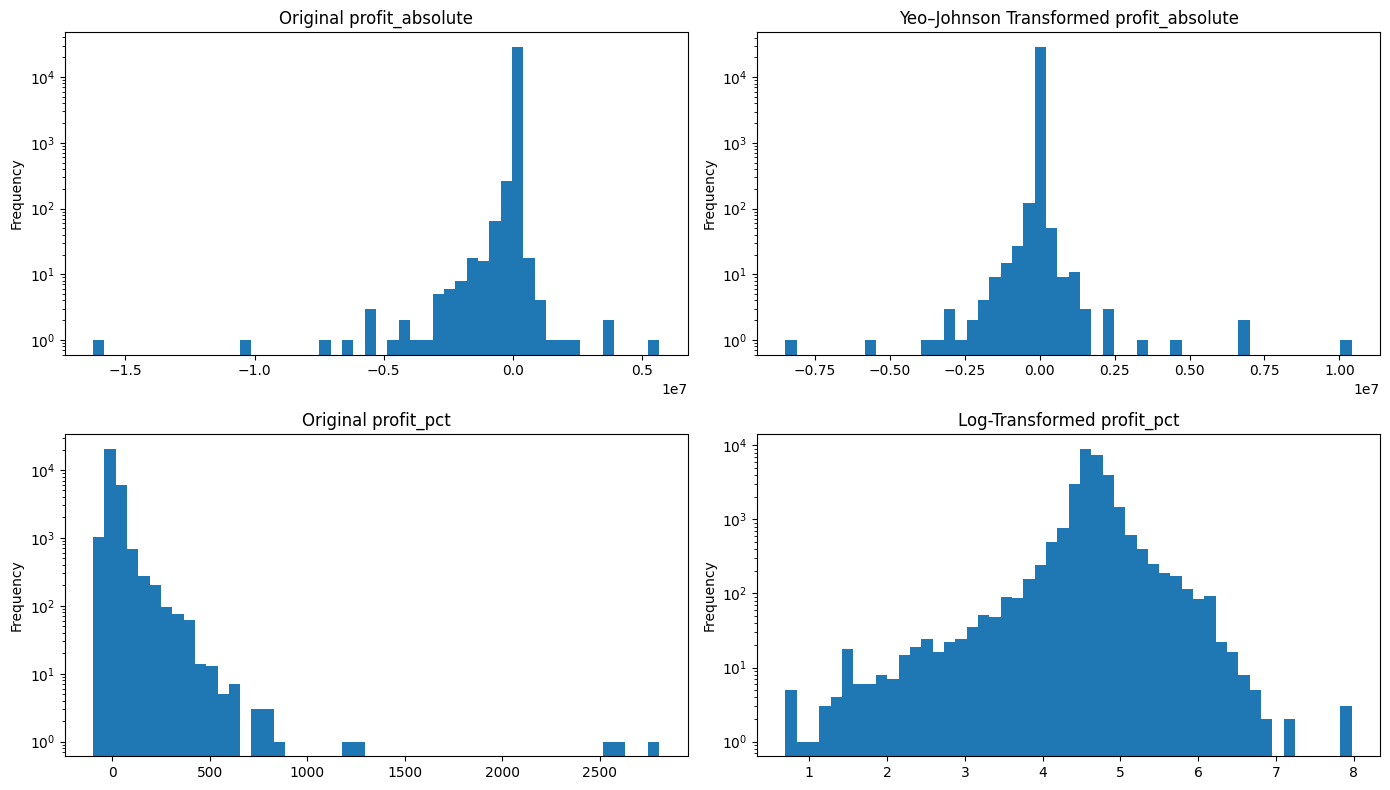

In [ ]:
# for multiple customerID entries, keep only the latest record
customer_information = customer_information.loc[customer_information.groupby('customerID')['timestamp'].idxmax()].reset_index(drop=True)

customer_copy = customer_information.copy()

# compute non-normalised vs normalised profit values
investor_profit_raw = compute_profit(G, normalise=False)
investor_profit_norm = compute_profit(G, normalise=True)

customer_copy = customer_copy.merge(
    investor_profit_raw[['customerID', 'profit_absolute', 'profit_pct']],
    on='customerID', how='left'
)

customer_copy = customer_copy.merge(
    investor_profit_norm[['customerID', 'log_profit_pct', 'yj_profit_abs']],
    on='customerID', how='left'
)

# Plot before vs after
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(customer_copy['profit_absolute'], bins=50, log=True)
axes[0, 0].set_title("Original profit_absolute")
axes[0, 0].set_ylabel("Frequency")

axes[1, 0].hist(customer_copy['profit_pct'], bins=50, log=True)
axes[1, 0].set_title("Original profit_pct")
axes[1, 0].set_ylabel("Frequency")

axes[0, 1].hist(customer_copy['yj_profit_abs'], bins=50, log=True)
axes[0, 1].set_title("Yeo–Johnson Transformed profit_absolute")
axes[0, 1].set_ylabel("Frequency")

axes[1, 1].hist(customer_copy['log_profit_pct'], bins=50, log=True)
axes[1, 1].set_title("Log-Transformed profit_pct")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# Use the transformed profits for customer_information
investor_profit_norm = investor_profit_norm.rename(
    columns={
        'log_profit_pct': 'profit_pct_full',
        'yj_profit_abs': 'profit_absolute_full'
    }
)

customer_information = customer_information.merge(
    investor_profit_norm[['customerID', 'profit_pct_full', 'profit_absolute_full']],
    on='customerID', how='left'
)

In [ ]:
tx_sorted = transactions.copy()
tx_sorted['timestamp'] = pd.to_datetime(tx_sorted['timestamp'], errors='coerce')
tx_sorted = tx_sorted.sort_values(['customerID', 'timestamp'])

# ============== avg_txn_interval_days ==============
# find time gaps in days per investor
tx_sorted['gap_days'] = (
    tx_sorted.groupby('customerID')['timestamp']
    .diff()
    .dt.days
)

# use mean of gap_days to find avg_txn_interval_days
avg_txn_interval = (
    tx_sorted.groupby('customerID')['gap_days']
    .mean()
    .rename('avg_txn_interval_days')
)

# ============== avg_spend ==============
avg_spend = (
    tx_sorted[tx_sorted['transactionType'].str.lower() == 'buy']
    .groupby('customerID')['totalValue']
    .mean()
    .rename('avg_spend')
)

customer_agg = pd.concat([avg_txn_interval, avg_spend], axis=1)

# avg_txn_interval_days = 0 or NaN is not a valid data. Impute with median across all valid avg_txn_interval_days
valid_pos = customer_agg['avg_txn_interval_days'][
    customer_agg['avg_txn_interval_days'] > 0
]

# imputed value is 241.5
median_avg_txn = float(valid_pos.median()) if len(valid_pos) else 0.0

customer_agg['avg_txn_interval_days'] = (
    customer_agg['avg_txn_interval_days']
    .where(customer_agg['avg_txn_interval_days'] > 0)
    .fillna(median_avg_txn)
    .round(1)
)

customer_information = customer_information.merge(customer_agg.reset_index(), on='customerID', how='left')
customer_information.head()

,customerID,customerType,riskLevel,investmentCapacity,lastQuestionnaireDate,timestamp,profit_pct_full,profit_absolute_full,avg_txn_interval_days,avg_spend
0,00017496858921195E5A,Professional,Aggressive,CAP_GT300K,2020-03-13,2021-03-19,4.609668,-3696.713440,7.9,4744.275738
1,00024864C985E72167A0,Mass,Predicted_Conservative,Predicted_CAP_LT30K,2000-01-01,2021-09-09,4.523939,-386.209005,241.5,4999.993985
2,0004718496C71D464F57,Mass,Predicted_Conservative,Predicted_CAP_80K_300K,2000-01-01,2018-01-02,3.220915,-169427.371389,51.2,14874.918333
3,000676D07A4CF7526ECB,Mass,Income,CAP_30K_80K,2020-11-02,2022-11-22,4.624989,11.613493,241.5,4962.784731
4,000900E880281981624D,Mass,Balanced,CAP_LT30K,2018-07-31,2021-07-16,4.451442,-95.938006,241.5,700.000000


In [ ]:
count_equal_median = (customer_agg['avg_txn_interval_days'] == median_avg_txn).sum()
print(f"{count_equal_median} out of {len(customer_information)} imputed for average interval between transactions")

3885 out of 29090 imputed for average interval between transactions


#### 2.4) Feature Engineering for train dataset
##### (training period is set to all transactions before 2022-07-01).
- *profit_absolute_train*: Profit/loss of each investor **within the training period** (i.e., before the cutoff date `2022-07-01`).  

- *profit_pct_train*: % of profit of each investor with respect to total amount invested within the training period.  

- *cum_profitability_train*: cum_profitability within the training period.

- *asset_risk_train*: asset_Risk within the training period.

- *profit_norm*: Normalised cum_profitability score.

- *risk_norm*: Normalised asset_risk score.


In [ ]:
CUTOFF_DATE = pd.to_datetime("2022-07-01")   # train/test split date

In [ ]:
# ============== Train-period asset stats (cum_profitability_train, asset_risk train) & normalized features (profit_norm, risk_norm) ==============

# Filter close prices ≤ cutoff
cutoff = CUTOFF_DATE
cp = close_prices.copy()
cp['timestamp'] = pd.to_datetime(cp['timestamp'], errors='coerce')
cp_train = cp[cp['timestamp'] <= cutoff].sort_values(['ISIN', 'timestamp'])

# Compute rt
cp_train['log_price'] = np.log(cp_train['closePrice'].astype(float))
cp_train['rt'] = cp_train.groupby('ISIN')['log_price'].diff()

#    - cum_profitability_train: exp(sum(rt)) - 1 over the train window
#    - asset_risk_train: variance of rt over the train window
agg_train = (
    cp_train.groupby('ISIN')
    .agg(
        cum_log_ret_train=('rt', 'sum'),
        asset_risk_train=('rt', 'var')  # population-ish variance; fine for ranking
    )
    .reset_index()
)

# Convert cumulative log return to percentage return
agg_train['cum_profitability_train'] = np.expm1(agg_train['cum_log_ret_train'])
agg_train.drop(columns=['cum_log_ret_train'], inplace=True)

# Merge TRAIN-period stats into asset_information
asset_information = asset_information.merge(
    agg_train[['ISIN', 'cum_profitability_train', 'asset_risk_train']],
    on='ISIN', how='left'
)

# Build robust min–max scalers (use percentiles to reduce outlier effects)
def robust_minmax(x, lo=0.05, hi=0.95):
    x = x.astype(float)
    p_low = np.nanpercentile(x, lo*100)
    p_high = np.nanpercentile(x, hi*100)
    if not np.isfinite(p_high - p_low) or (p_high - p_low) == 0:
        # Fallback to simple min-max if percentile range collapses
        p_low = np.nanmin(x)
        p_high = np.nanmax(x)
        if p_high == p_low:
            return pd.Series(np.zeros(len(x)), index=x.index)
    z = (x - p_low) / (p_high - p_low)
    return z.clip(0, 1)

# 6) Create profit_norm / risk_norm from TRAIN-period stats
asset_information['profit_norm'] = robust_minmax(asset_information['cum_profitability_train'].fillna(0.0))
asset_information['risk_norm']   = robust_minmax(asset_information['asset_risk_train'].fillna(0.0))

print(
    "[asset features] profit_norm: "
    f"min={asset_information['profit_norm'].min():.3f}, "
    f"median={asset_information['profit_norm'].median():.3f}, "
    f"max={asset_information['profit_norm'].max():.3f}"
)
print(
    "[asset features] risk_norm: "
    f"min={asset_information['risk_norm'].min():.3f}, "
    f"median={asset_information['risk_norm'].median():.3f}, "
    f"max={asset_information['risk_norm'].max():.3f}"
)


[asset features] profit_norm: min=0.000, median=0.218, max=1.000
[asset features] risk_norm: min=0.000, median=0.047, max=1.000


In [ ]:
asset_information.head()

,ISIN,assetName,assetShortName,assetCategory,assetSubCategory,marketID,sector,industry,timestamp,latest_price,cum_profitability,asset_risk,cum_profitability_train,asset_risk_train,profit_norm,risk_norm
0,100974271034,VIOHALCO SA (el-GR),ΒΙΟ,Stock,Large Cap,XATH,Unknown,Unknown,2018-01-02,4.165000,0.250751,0.000812,0.010511,0.000851,0.218448,0.356815
1,AU3CB0228823,European Investment Bank (EIB),UNK_2,Bond,Corporate,XMUN,Corporate,Banks,2021-01-27,62.513932,-0.118141,0.000031,-0.090432,0.000028,0.164796,0.011673
2,AU3CB0237725,Hyundai Capital Services,UNK_3,Bond,Corporate,XASX,Corporate,Leasing and Rental,2018-01-02,61.758375,-0.050771,0.000028,-0.050771,0.000028,0.185876,0.011412
3,AU3CB0237881,Apple,UNK_4,Bond,Corporate,XETR,Corporate,IT equipment,2018-11-22,67.892546,0.049536,0.000041,0.049536,0.000041,0.239191,0.016996
4,AU3CB0258465,Westpac Banking,UNK_7,Bond,Corporate,XASX,Corporate,Banks,2019-04-12,63.775807,-0.025767,0.000030,-0.000578,0.000030,0.212555,0.012294


In [ ]:
# ============== profit_absolute_train, profit_pct_train ==============

tx_train = transactions.copy()
tx_train['timestamp'] = pd.to_datetime(tx_train['timestamp'], errors='coerce')
tx_train = tx_train[tx_train['timestamp'] <= CUTOFF_DATE]

# Create graph for train dataset
G_train = build_market_graph(tx_train, asset_information)

# Compute profit
investor_profit_df_train = compute_profit(G_train, normalise = True)

investor_profit_df_train = investor_profit_df_train.rename(columns={
    'yj_profit_abs': 'profit_absolute_train',
    'log_profit_pct': 'profit_pct_train'
})

customer_information = customer_information.merge(
    investor_profit_df_train, on='customerID', how='left'
)

Graph built with 28960 nodes and 86712 edges


In [ ]:
customer_information[['customerID','profit_pct_train','profit_absolute_train']].head()
# Note: where profit_absolute_train and profit_pct_train are NaN, these investors are not considered in the training dataset.
# Train/Test dataset will be split in part 3).

,customerID,profit_pct_train,profit_absolute_train
0,00017496858921195E5A,4.612228,-2829.702670
1,00024864C985E72167A0,4.523939,-385.884141
2,0004718496C71D464F57,3.169248,-168790.969539
3,000676D07A4CF7526ECB,NaN,NaN
4,000900E880281981624D,4.451442,-95.879408


## 3) Time-based Train/Test Split
We use a cutoff date (≤ **train**, \> **test**) on BUY interactions only. Indexers are built **from train only**; test users/items are filtered to seen vocab. We materialize `R_train` (CSR) and keep test as a dataframe for metrics.


In [ ]:
# ============== 3) Time-based split: train / test (leak-safe) ==============
from scipy import sparse
# 0) Normalize dtypes
cutoff = pd.to_datetime(CUTOFF_DATE)
tx = transactions.copy()
tx['timestamp'] = pd.to_datetime(tx['timestamp'], errors='coerce')

# 1) Keep implicit positives as BUYs only (consistent with your CF logic)
tx['is_buy'] = tx['transactionType'].str.lower().eq('buy')
tx_buy = tx.loc[tx['is_buy']].copy()

# 2) Split chronologically
tx_train = tx_buy.loc[tx_buy['timestamp'] <= cutoff].copy()
tx_test  = tx_buy.loc[tx_buy['timestamp'] >  cutoff].copy()

# 3) Build stable user/item indexers from TRAIN ONLY
users_train = pd.Index(tx_train['customerID'].unique(), name='customerID')
items_train = pd.Index(tx_train['ISIN'].unique(), name='ISIN')

user2idx = pd.Series(np.arange(len(users_train)), index=users_train)
item2idx = pd.Series(np.arange(len(items_train)), index=items_train)

# 4) Map TRAIN ids → indices
tx_train['u'] = tx_train['customerID'].map(user2idx)
tx_train['i'] = tx_train['ISIN'].map(item2idx)

# 5) Restrict TEST to known users/items (standard offline eval)
tx_test = tx_test[
    tx_test['customerID'].isin(users_train) & tx_test['ISIN'].isin(items_train)
].copy()
tx_test['u'] = tx_test['customerID'].map(user2idx)
tx_test['i'] = tx_test['ISIN'].map(item2idx)

# 6) Define implicit feedback strength (choose ONE and keep it consistent)
#    Option A (recommended): spend-aware but tamed
tx_train['strength'] = np.log1p(tx_train['totalValue'].astype(float).clip(lower=0))
tx_test['strength']  = np.log1p(tx_test['totalValue'].astype(float).clip(lower=0))


# 7) Aggregate duplicate (u,i) within each split
agg = {'strength':'sum'}  # sum or mean; sum works well with log1p(totalValue)
train_agg = (tx_train.groupby(['u','i'], as_index=False).agg(agg))
test_agg  = (tx_test.groupby(['u','i'],  as_index=False).agg(agg))

# 8) Build sparse CSR matrices for CF models
num_users = len(users_train)
num_items = len(items_train)

R_train = sparse.csr_matrix(
    (train_agg['strength'].values, (train_agg['u'].values, train_agg['i'].values)),
    shape=(num_users, num_items)
)

# For evaluation we usually keep TEST as a dataframe of ground truth.
# If you also want a CSR (e.g., for masking), you can create it:
R_test = sparse.csr_matrix(
    (test_agg['strength'].values, (test_agg['u'].values, test_agg['i'].values)),
    shape=(num_users, num_items)
)

# 9) Preflight checks (raise early if something is off)
issues = []

# a) Chronology
if (tx_train['timestamp'].max() > cutoff) or (tx_test['timestamp'].min() <= cutoff and len(tx_test)):
    issues.append("Split chronology failed. Check timestamps and cutoff.")

# b) Non-empty
if R_train.nnz == 0:
    issues.append("Empty TRAIN interactions (R_train.nnz == 0).")
if len(test_agg) == 0:
    print("[warn] TEST has zero rows after filtering to seen users/items. "
          "Evaluation will be trivial; consider a later cutoff or keep cold-start eval separately.")

# c) Indexers alignment
if tx_train[['u','i']].isna().any().any():
    issues.append("NaNs in train index mapping (unknown user/item ids leaked into train?).")
if len(users_train) != num_users or len(items_train) != num_items:
    issues.append("Indexer sizes mismatch.")

# d) Sanity: no items or users in TEST that aren’t in TRAIN
if tx_test[['u','i']].isna().any().any():
    issues.append("NaNs in test index mapping (there are unseen users/items in TEST).")

if issues:
    raise AssertionError(" | ".join(issues))
else:
    print("✅ Time-based split OK:",
          f"train rows={len(train_agg)}, test rows={len(test_agg)}, "
          f"users={num_users}, items={num_items}, R_train.nnz={R_train.nnz}")

# 10) Save artifacts for downstream cells (optional but handy)
artifacts = {
    'users_train': users_train,
    'items_train': items_train,
    'user2idx': user2idx,
    'item2idx': item2idx,
    'R_train': R_train,
    'R_test': R_test,
    'train_df': train_agg,   # compact per-(u,i)
    'test_df': test_agg
}


✅ Time-based split OK: train rows=86712, test rows=5988, users=28648, items=312, R_train.nnz=86712


In [ ]:
# How many users actually have ground-truth in TEST?
gt_users = test_agg['u'].nunique()
print(f"Users with at least one test item: {gt_users}")

# Average test items per GT user (helps gauge signal for metrics)
items_per_gt_user = (test_agg.groupby('u')['i'].nunique()).mean()
print(f"Avg test items per GT user: {items_per_gt_user:.2f}")

# (Optional) If gt_users is tiny, consider a slightly later cutoff date to balance train/test.


Users with at least one test item: 2174
Avg test items per GT user: 2.75


In [ ]:
# ========= Eval harness + two baselines (global & recent popularity) =========
import numpy as np
import pandas as pd

K_LIST = [5, 10, 20]

# Ground truth dict: user -> set(items)
gt_items = (test_agg.groupby('u')['i']
            .apply(lambda s: set(s.values))
            .to_dict())

# Seen items in TRAIN (mask these at recommend time)
seen_u, seen_i = R_train.nonzero()
seen_by_user = {}
for u, i in zip(seen_u, seen_i):
    seen_by_user.setdefault(u, set()).add(i)

def _topk_excluding(seen_set, scores, k):
    # scores is 1D np.array for items
    if seen_set:
        scores = scores.copy()
        scores[list(seen_set)] = -np.inf
    # argpartition is O(n); then sort top-k slice
    idx = np.argpartition(-scores, kth=min(k-1, len(scores)-1))[:k]
    return idx[np.argsort(-scores[idx])]

def precision_recall_hit_at_k(pred_items, true_items, k):
    if not true_items:
        return np.nan, np.nan, np.nan
    pred_k = pred_items[:k]
    hits = len(set(pred_k) & true_items)
    p = hits / k
    r = hits / len(true_items)
    hr = 1.0 if hits > 0 else 0.0
    return p, r, hr

def evaluate_recommender(get_scores_fn, k_list=K_LIST, users=None):
    """get_scores_fn(u) -> 1D np.array of length num_items (higher=better)"""
    if users is None:
        users = list(gt_items.keys())
    out = {k: {'P':[], 'R':[], 'HR':[]} for k in k_list}
    for u in users:
        if u not in gt_items:  # skip users with no GT
            continue
        scores = get_scores_fn(u)
        if scores is None:
            continue
        preds = _topk_excluding(seen_by_user.get(u, set()), scores, max(k_list))
        true = gt_items[u]
        for k in k_list:
            p, r, hr = precision_recall_hit_at_k(preds, true, k)
            if not np.isnan(p):
                out[k]['P'].append(p); out[k]['R'].append(r); out[k]['HR'].append(hr)
    # Aggregate
    result = {k: {m: float(np.mean(vals)) if len(vals) else np.nan
                  for m, vals in d.items()} for k, d in out.items()}
    return pd.DataFrame(result).T  # rows = K, cols = P/R/HR

# -------- Baseline 1: Global popularity (train) --------
pop_scores = np.zeros(R_train.shape[1], dtype=float)
# Sum of strengths per item in TRAIN
item_strength = train_agg.groupby('i')['strength'].sum()
pop_scores[item_strength.index.values] = item_strength.values

def scores_pop(u):
    return pop_scores  # same for all users (we'll mask seen items per user)

# -------- Baseline 2: Recent popularity (last 30 days pre-cutoff) --------
window_start = cutoff - pd.Timedelta(days=30)
tx_recent = tx[(tx['is_buy']) & (tx['timestamp'] <= cutoff) & (tx['timestamp'] >= window_start)]
tx_recent = tx_recent[tx_recent['ISIN'].isin(items_train)]
recent_scores = np.zeros(R_train.shape[1], dtype=float)
if not tx_recent.empty:
    # map to item indices
    i_recent = tx_recent['ISIN'].map(item2idx).dropna().astype(int)
    w = np.log1p(tx_recent.loc[i_recent.index, 'totalValue'].astype(float).clip(lower=0)).values
    for i, wv in zip(i_recent.values, w):
        recent_scores[i] += wv

def scores_recent(u):
    return recent_scores

# -------- Run baselines --------
print("Global popularity baseline:")
display(evaluate_recommender(scores_pop))

print("Recent 30-day popularity baseline:")
display(evaluate_recommender(scores_recent))


Global popularity baseline:


,P,R,HR
5,0.034223,0.080469,0.147654
10,0.024839,0.118638,0.205152
20,0.015777,0.140647,0.246090


Recent 30-day popularity baseline:


,P,R,HR
5,0.035603,0.083166,0.155474
10,0.027139,0.123887,0.220331
20,0.018951,0.161012,0.282429


In [ ]:
print("Train matrix:", R_train.shape, "NNZ:", R_train.nnz)
print("Test users:", len(gt_items))


Train matrix: (28648, 312) NNZ: 86712
Test users: 2174


## 4) Clustering — KMeans

### Purpose
This section segments investors into behavioral groups based on their financial and transactional features.  
By identifying clusters of investors with similar risk tolerance, profitability, and trading patterns, we can later tailor personalized recommendation strategies per cluster.

### Approach
We use the **K-Means** algorithm on the standardized customer feature matrix.  
The optimal number of clusters (**k**) is determined by the **silhouette score**, balancing cohesion and separation.  
Each investor is then assigned a cluster label (`cluster_kmeans`), which is stored for later profiling and recommender personalization.

### Key Outputs
- **Best K** value and **silhouette score** (printed in output)  
- **Cluster size distribution** – number of customers per cluster  
- **Cluster profile table** summarizing average profitability, spend, and risk  
- **Visualization** of cluster means or feature distributions  
- JSON / CSV summary saved to `/outputs/clustering_summary.json` and `/outputs/cluster_profile.csv`  

### Interpretation
Clusters correspond to investor archetypes such as:
- *Conservative, low-risk investors*  
- *Moderate, balanced investors*  
- *Aggressive, high-risk investors*

These profiles are later used to interpret recommendation results and validate that the hybrid model behaves consistently across customer segments.


In [ ]:
# ========= 4) Clustering — data prep (train-safe + robust) =========

# Pick profit columns (prefer train-safe)
if {'profit_absolute_train','profit_pct_train'}.issubset(customer_information.columns):
    prof_abs_col = 'profit_absolute_train'
    prof_pct_col = 'profit_pct_train'
else:
    # fallback (EDA-only) — OK for clustering but DON'T feed to recommenders
    prof_abs_col = 'profit_absolute_full' if 'profit_absolute_full' in customer_information.columns else 'profit_absolute'
    prof_pct_col = 'profit_pct_full' if 'profit_pct_full' in customer_information.columns else 'profit_pct'

use_cols = [
    'customerID', 'customerType', 'riskLevel', 'investmentCapacity',
    'avg_spend', 'avg_txn_interval_days', prof_abs_col, prof_pct_col
]

clust_df = customer_information[use_cols].copy()

# Basic cleaning
for c in ['avg_spend','avg_txn_interval_days', prof_abs_col, prof_pct_col]:
    if c in clust_df.columns:
        clust_df[c] = pd.to_numeric(clust_df[c], errors='coerce')

# Winsorize numeric tails (robust to outliers)
def winsorize(s, lo=0.01, hi=0.99):
    x = s.astype(float).copy()
    lo_v, hi_v = np.nanpercentile(x, [lo*100, hi*100])
    return x.clip(lo_v, hi_v)

for c in ['avg_spend','avg_txn_interval_days', prof_abs_col, prof_pct_col]:
    if c in clust_df.columns:
        clust_df[c] = winsorize(clust_df[c])

# Impute numerics with median
for c in ['avg_spend','avg_txn_interval_days', prof_abs_col, prof_pct_col]:
    if c in clust_df.columns:
        clust_df[c] = clust_df[c].fillna(clust_df[c].median())

# One-hot for small categoricals
cat_cols = [c for c in ['riskLevel','customerType','investmentCapacity'] if c in clust_df.columns]
X = clust_df[['avg_spend','avg_txn_interval_days', prof_abs_col, prof_pct_col] + cat_cols].copy()

X = pd.get_dummies(X, columns=cat_cols, dummy_na=True)

print(f"[clustering] Shape before scaling: {X.shape}")


[clustering] Shape before scaling: (29090, 30)


#### Boxplot of outliers clipping


⚠️ Skipping missing columns: {'cum_profitability', 'asset_risk'}
📊 Outlier clipping bounds (IQR × 1.5):
profit_absolute_full     : lower=  -1571.39 | upper=   2095.15
profit_pct_full          : lower=      4.12 | upper=      5.17


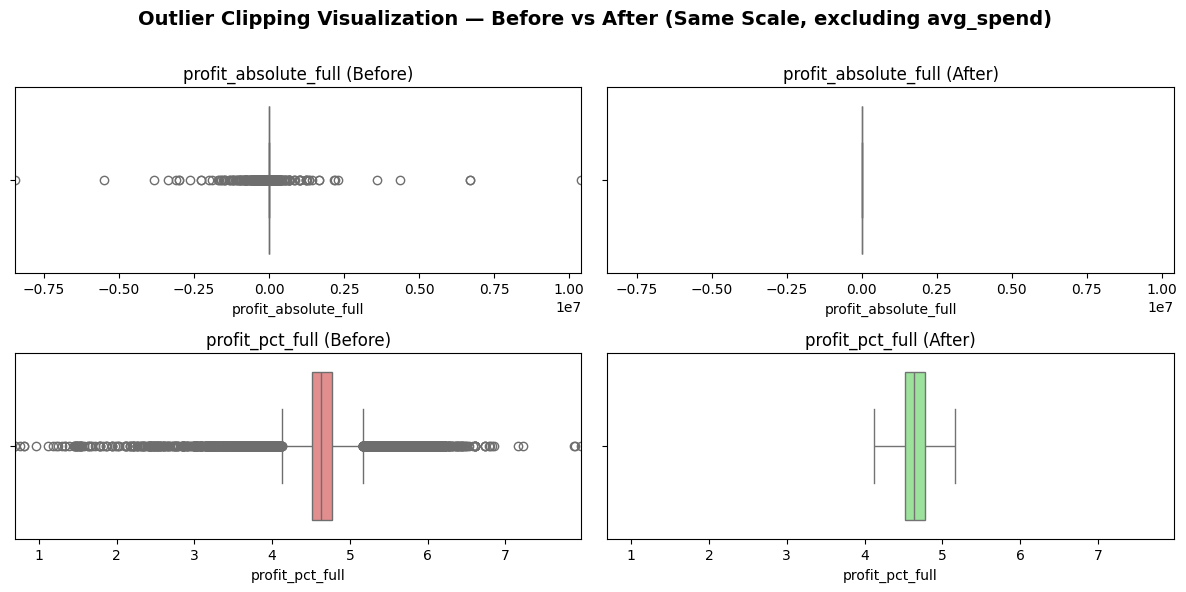

✅ Outlier clipping visualization complete, 'customer_information_clipped' created.


In [ ]:
# ============================================
# Outlier Clipping Visualization
# ============================================

# Candidate numeric features
candidate_features = [
    'profit_absolute_full',
    'profit_pct_full',
    'asset_risk',
    'cum_profitability'
]

# Keep only columns that actually exist
features_for_clustering = [c for c in candidate_features if c in customer_information.columns]

if len(features_for_clustering) == 0:
    raise ValueError("⚠️ None of the specified clustering features exist in customer_information!")

missing = set(candidate_features) - set(features_for_clustering)
if missing:
    print(f"⚠️ Skipping missing columns: {missing}")

# Copy subset for visualization
df_before = customer_information[features_for_clustering].copy()

# Define clipping function (IQR × 1.5 rule)
def clip_outliers(df, cols, multiplier=1.5):
    df_clipped = df.copy()
    clip_bounds = {}
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        clip_bounds[col] = (lower, upper)
        df_clipped[col] = df[col].clip(lower, upper)
    return df_clipped, clip_bounds

# Apply clipping
df_after, clip_bounds = clip_outliers(df_before, features_for_clustering, multiplier=1.5)

# Print bounds summary
print("📊 Outlier clipping bounds (IQR × 1.5):")
for k, (lo, hi) in clip_bounds.items():
    print(f"{k:25s}: lower={lo:10.2f} | upper={hi:10.2f}")

# Side-by-side boxplots (same x-axis scale)
n = len(features_for_clustering)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3 * n))
fig.suptitle("Outlier Clipping Visualization — Before vs After (Same Scale, excluding avg_spend)",
             fontsize=14, weight="bold")

for i, col in enumerate(features_for_clustering):
    # Determine same x-axis range
    xmin = min(df_before[col].min(), df_after[col].min())
    xmax = max(df_before[col].max(), df_after[col].max())

    # Before
    sns.boxplot(x=df_before[col], ax=axes[i, 0], color="lightcoral")
    axes[i, 0].set_xlim(xmin, xmax)
    axes[i, 0].set_title(f"{col} (Before)")

    # After
    sns.boxplot(x=df_after[col], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_xlim(xmin, xmax)
    axes[i, 1].set_title(f"{col} (After)")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# ✅ Optional: save the clipped version for clustering use
customer_information_clipped = customer_information.copy()
customer_information_clipped[features_for_clustering] = df_after
print("✅ Outlier clipping visualization complete, 'customer_information_clipped' created.")


In [ ]:
# ========= KMeans: scale, reduce, pick k via silhouette =========
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to 95% variance (helps KMeans stability & speed)
pca = PCA(n_components=0.95, random_state=42)
Z = pca.fit_transform(X_scaled)

k_range = range(2, 9)  # 2..8
km_models, sil_scores = {}, []
for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(Z)
    s = silhouette_score(Z, labels, metric='euclidean')
    km_models[k] = (km, labels, s)
    sil_scores.append(s)

best_k = max(k_range, key=lambda k: km_models[k][2])
km_best, km_labels, km_sil = km_models[best_k]
print(f"[KMeans] best_k={best_k}, silhouette={km_sil:.3f}, PCA_dim={Z.shape[1]}")


[KMeans] best_k=8, silhouette=0.263, PCA_dim=20


In [ ]:
# --- Repair/attach cluster labels & reprofile (safe) ---

# 0) Sanity: do we have KMeans labels from the previous cell?
try:
    km_labels  # should exist from KMeans selection
except NameError as e:
    raise RuntimeError("KMeans labels not found. Run the KMeans cell first.") from e

# 1) Attach labels to the clustering frame we used to fit (clust_df)
#    (km_labels length must equal len(clust_df))
assert len(km_labels) == len(clust_df), "Label length mismatch. Re-run the clustering prep + KMeans cells."
clust_df = clust_df.copy()
clust_df['cluster_kmeans'] = km_labels

# If DBSCAN found something, keep it too; else all -1
if 'best_db' in globals() and best_db:
    _, db_labels, _, _ = best_db
    assert len(db_labels) == len(clust_df), "DBSCAN label length mismatch."
    clust_df['cluster_dbscan'] = db_labels
else:
    clust_df['cluster_dbscan'] = -1

# 2) Merge labels back into customer_information (suffix-safe)
labels_to_merge = clust_df[['customerID','cluster_kmeans','cluster_dbscan']].drop_duplicates('customerID')

customer_information = customer_information.drop(
    columns=[c for c in ['cluster_kmeans','cluster_dbscan'] if c in customer_information.columns],
    errors='ignore'
).merge(labels_to_merge, on='customerID', how='left')

# 3) Quick checks
assert 'cluster_kmeans' in customer_information.columns, "cluster_kmeans missing after merge."
print("[ok] Attached cluster_kmeans. Size by cluster:")
print(customer_information['cluster_kmeans'].value_counts().sort_index())

# 4) Rebuild the cluster profile (robust to missing categoricals)
num_abs = 'profit_absolute_train' if 'profit_absolute_train' in customer_information.columns else (
          'profit_absolute_full' if 'profit_absolute_full' in customer_information.columns else None)
num_pct = 'profit_pct_train' if 'profit_pct_train' in customer_information.columns else (
          'profit_pct_full' if 'profit_pct_full' in customer_information.columns else None)

profile_cols = ['avg_spend','avg_txn_interval_days']
if num_abs: profile_cols.append(num_abs)
if num_pct: profile_cols.append(num_pct)
for c in ['riskLevel','customerType','investmentCapacity']:
    if c in customer_information.columns:
        profile_cols.append(c)

present = [c for c in profile_cols if c in customer_information.columns]

def mode_or_na(s):
    try:
        return s.mode(dropna=True).iloc[0]
    except Exception:
        return np.nan

agg_spec = {}
for c in present:
    if str(customer_information[c].dtype)[:3] in ('int','flo'):
        agg_spec[c] = 'median'
    else:
        agg_spec[c] = mode_or_na

summary = (
    customer_information.dropna(subset=['cluster_kmeans'])
    .groupby('cluster_kmeans')[present]
    .agg(agg_spec)
)

print("\n[KMeans] Cluster profile (median numerics, mode categoricals):")
display(summary)

# Optional: cluster sizes (%)
sizes = customer_information['cluster_kmeans'].value_counts().sort_index()
print("\n[KMeans] Cluster sizes:")
display(sizes)
print("% share:", (sizes/len(customer_information)).round(3).to_dict())


[ok] Attached cluster_kmeans. Size by cluster:
cluster_kmeans
0    2659
1    9893
2    3768
3     321
4    2695
5    1388
6    3101
7    5265
Name: count, dtype: int64

[KMeans] Cluster profile (median numerics, mode categoricals):


,avg_spend,avg_txn_interval_days,profit_absolute_train,profit_pct_train,riskLevel,customerType,investmentCapacity
cluster_kmeans,,,,,,,
0,1078.920000,444.20,5.679992,4.652313,Predicted_Income,Mass,Predicted_CAP_LT30K
1,1085.400000,241.50,53.935979,4.659999,Income,Mass,CAP_LT30K
2,2975.697256,241.50,-147.513301,4.564052,Balanced,Premium,CAP_80K_300K
3,1137.300000,784.50,228.443741,4.769270,Not_Available,Mass,Not_Available
4,1028.720000,441.00,42.541866,4.676455,Conservative,Mass,CAP_LT30K
5,1139.397953,450.35,3.236344,4.641292,Predicted_Balanced,Mass,Predicted_CAP_LT30K
6,1129.165769,446.30,13.507745,4.655767,Predicted_Conservative,Mass,Predicted_CAP_LT30K
7,2228.954655,186.70,-32.148119,4.601892,Balanced,Premium,CAP_30K_80K



[KMeans] Cluster sizes:


,count
cluster_kmeans,
0,2659
1,9893
2,3768
3,321
4,2695
5,1388
6,3101
7,5265


% share: {0: 0.091, 1: 0.34, 2: 0.13, 3: 0.011, 4: 0.093, 5: 0.048, 6: 0.107, 7: 0.181}


#### Barplot of Clustering distribution

📊 Cluster Distribution Summary:


,Cluster,Count,Percentage
0,0,2659,9.14
1,1,9893,34.01
2,2,3768,12.95
3,3,321,1.10
4,4,2695,9.26
5,5,1388,4.77
6,6,3101,10.66
7,7,5265,18.10


/tmp/ipython-input-3156708683.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


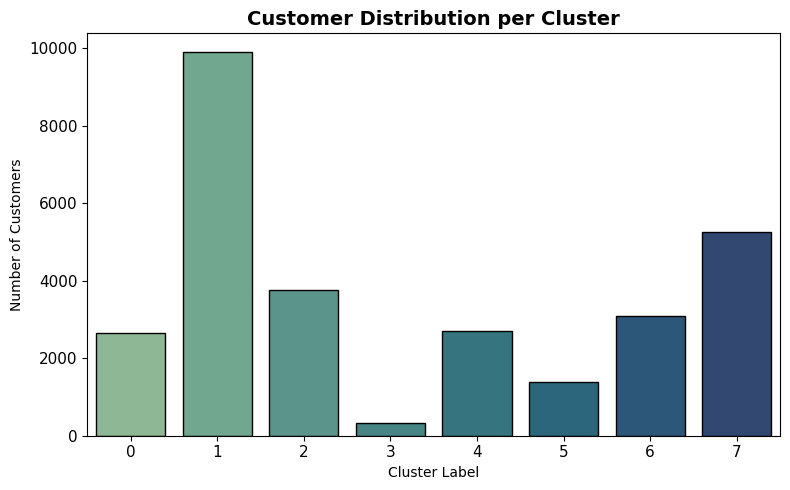

/tmp/ipython-input-3156708683.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


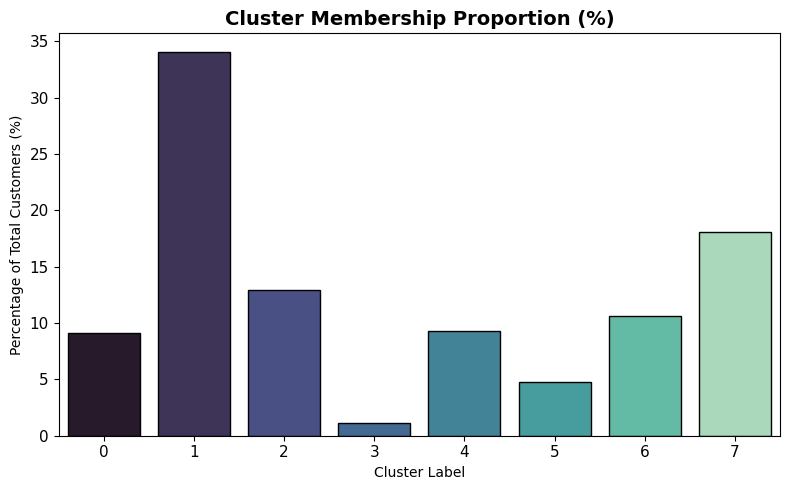

✅ Cluster distribution saved to outputs/cluster_distribution.csv


In [ ]:
# ============================================
# Cluster Distribution Visualization
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Ensure output directory exists
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Your cluster label column (adjust name if different)
cluster_col = 'cluster_kmeans'

if cluster_col not in customer_information.columns:
    raise ValueError(f"⚠️ Column '{cluster_col}' not found in customer_information!")

# Count cluster membership
cluster_counts = (
    customer_information[cluster_col]
    .value_counts()
    .sort_index()
    .rename_axis('Cluster')
    .reset_index(name='Count')
)

# Calculate percentages
cluster_counts['Percentage'] = (
    cluster_counts['Count'] / cluster_counts['Count'].sum() * 100
).round(2)

# Display numeric summary
print("📊 Cluster Distribution Summary:")
display(cluster_counts)

# Plot: Cluster count distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_counts,
    x='Cluster',
    y='Count',
    palette='crest',
    edgecolor='black'
)
plt.title('Customer Distribution per Cluster', fontsize=14, weight='bold')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Customers')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Plot: Cluster proportion (%)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=cluster_counts,
    x='Cluster',
    y='Percentage',
    palette='mako',
    edgecolor='black'
)
plt.title('Cluster Membership Proportion (%)', fontsize=14, weight='bold')
plt.xlabel('Cluster Label')
plt.ylabel('Percentage of Total Customers (%)')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Save results to outputs folder
cluster_counts.to_csv(OUTPUT_DIR / "cluster_distribution.csv", index=False)
print(f"✅ Cluster distribution saved to {OUTPUT_DIR/'cluster_distribution.csv'}")


In [ ]:
assert customer_information['cluster_kmeans'].isna().mean() == 0.0, "Missing KMeans labels."
print(f"Unique clusters (KMeans): {sorted(customer_information['cluster_kmeans'].unique())}")
if 'cluster_dbscan' in customer_information.columns:
    print("DBSCAN label distribution:")
    print(customer_information['cluster_dbscan'].value_counts().sort_index())

Unique clusters (KMeans): [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7)]
DBSCAN label distribution:
cluster_dbscan
-1    29090
Name: count, dtype: int64


In [ ]:
# --- Clustering cleanup (optional but tidy) ---
# 1) Ensure label dtype is plain int
customer_information['cluster_kmeans'] = customer_information['cluster_kmeans'].astype(int)

# 2) Drop DBSCAN column entirely (we're KMeans-only now)
if 'cluster_dbscan' in customer_information.columns:
    customer_information.drop(columns=['cluster_dbscan'], inplace=True, errors='ignore')

# 3) Quick sanity
assert customer_information['cluster_kmeans'].isna().sum() == 0
print("Clusters:", sorted(customer_information['cluster_kmeans'].unique()))
print("Sizes:\n", customer_information['cluster_kmeans'].value_counts().sort_index())


Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Sizes:
 cluster_kmeans
0    2659
1    9893
2    3768
3     321
4    2695
5    1388
6    3101
7    5265
Name: count, dtype: int64


In [ ]:
# Build per-cluster top items from TRAIN
train_users = users_train.values
u_cluster = (customer_information.set_index('customerID')
             .reindex(train_users)['cluster_kmeans']
             .fillna(-1).astype(int).values)

from collections import defaultdict
cl_item_strength = defaultdict(lambda: np.zeros(R_train.shape[1], float))

u_idx, i_idx = R_train.nonzero()
vals = np.asarray(R_train[u_idx, i_idx]).ravel()
for u, i, v in zip(u_idx, i_idx, vals):
    c = u_cluster[u]
    if c >= 0:
        cl_item_strength[c][i] += v

TOPK_CS = 100
cluster_top_items = {c: np.argsort(-scores)[:TOPK_CS] for c, scores in cl_item_strength.items()}


## 5) Recommender Systems

### Purpose
This section develops and evaluates multiple recommendation strategies for personalized investment advice.  
The goal is to suggest financial assets that align with each investor’s historical behavior, profitability preference, and risk tolerance.

### Overview of Models
We implement three collaborative filtering–based recommenders:

1. **Item-based CF** — focuses on asset-to-asset similarity.  
2. **User-based CF** — focuses on similarity between investors.  
3. **Hybrid model** — combines both user- and item-level signals through weighted fusion.

### Evaluation Framework
All models are trained on the **train split** (pre-cutoff transactions) and evaluated on **test split** (post-cutoff).  
Performance is reported via classic ranking metrics (Precision@K, Recall@K, Hit-Rate@K) and dual metrics (Preference@K, Profit@K, Score@K).  
Key metrics and plots are saved in `/outputs/` for reproducibility.


In [ ]:
from scipy import sparse
import numpy as np

def _row_to_1d(x):
    """Convert a 1×n sparse or dense matrix row into a flat 1D NumPy array."""
    if sparse.issparse(x):
        return x.toarray().ravel()
    return np.asarray(x).ravel()

In [ ]:
# ===== Recommender Utils =====
import numpy as np
from scipy import sparse

KNN_USERS  = 100
KNN_ITEMS  = 100
TOPK_RECO  = 20   # default recommend K

def csr_row_norm(mat):
    # compute L2 norm per row as flat np.array
    norms = np.sqrt(np.array(mat.multiply(mat).sum(axis=1)).ravel())
    norms[norms == 0] = 1.0  # avoid divide-by-zero
    return sparse.diags(1.0 / norms) @ mat


def _topk_excluding(seen_set, scores, k):
    s = scores.copy()
    if seen_set:
        s[list(seen_set)] = -np.inf
    # argpartition + final sort on the slice
    idx = np.argpartition(-s, kth=min(k-1, len(s)-1))[:k]
    return idx[np.argsort(-s[idx])]

# Safe accessors for train-safe profits
def get_user_profit_vector(default_to_full=False):
    idx2user = users_train.values
    ci = customer_information.set_index('customerID').reindex(idx2user)
    if 'profit_pct_train' in ci.columns:
        v = ci['profit_pct_train'].fillna(0.0).values
    elif default_to_full and 'profit_pct_full' in ci.columns:
        v = ci['profit_pct_full'].fillna(0.0).values
    else:
        v = np.zeros(len(idx2user), dtype=float)
    return v

# Item feature matrix (train-safe)
FEATURE_COLS = ['profit_norm','risk_norm']
item_feat = asset_information.set_index('ISIN').reindex(items_train)[FEATURE_COLS].fillna(0.0).to_numpy()
profit_norm = item_feat[:, 0]
risk_norm   = item_feat[:, 1]

### 5.1 Item-based Collaborative Filtering (Item-CF)

### Purpose
Item-CF recommends assets similar to those an investor has previously purchased or interacted with.  
The intuition: if two assets are often co-traded by many investors, they share investment appeal (e.g., similar sector, risk, or performance).

### Approach
- Construct an **item–item similarity matrix** using cosine similarity on the transaction matrix `R_trainᵀ × R_train`.  
- Normalize scores to mitigate popularity bias.  
- For each investor, predict affinity scores for unseen assets as a weighted sum of their owned assets’ similarities.

### Outputs  
- Predicted top-K recommendations per investor.  
- Evaluation metrics: Precision@5/10/20, Recall@5/10/20, Hit-Rate@5/10/20.


In [ ]:
# ===== Item-CF =====
R = R_train.tocsr()
RTn = csr_row_norm(R.T.tocsr())  # normalize item rows (items as rows)

def topk_cosine(mat, K):
    n = mat.shape[0]
    rows, cols, vals = [], [], []
    block = 2048
    for start in range(0, n, block):
        end = min(start+block, n)
        sims = (mat[start:end] @ mat.T).tolil()
        for i in range(sims.shape[0]):
            row = sims.rows[i]; data = sims.data[i]
            # remove self
            if (start+i) in row:
                j = row.index(start+i)
                row.pop(j); data.pop(j)
            if len(row) > K:
                idx = np.argpartition(-np.asarray(data), K-1)[:K]
                row = [row[j] for j in idx]; data = [data[j] for j in idx]
            rows += [start+i]*len(row); cols += row; vals += data
    return sparse.csr_matrix((vals, (rows, cols)), shape=(n, n))

S_item = topk_cosine(RTn, KNN_ITEMS).tocsr()

def scores_itemcf(u):
    # user u scores = R[u,:] * S_item
    return _row_to_1d(R[u] @ S_item)

### 5.2 User-based Collaborative Filtering (User-CF)

### Purpose
User-CF recommends assets favored by investors with similar trading patterns.  
The assumption: investors with comparable portfolios and profitability tendencies tend to prefer similar assets.

### Approach
- Build a **user–user similarity matrix** using cosine similarity on the interaction matrix `R_train × R_trainᵀ`.  
- For each target investor, aggregate the preferences of their top-similar peers to score unseen assets.  
- Normalize predictions and handle cold-start users by fallback to popularity or hybrid weighting.

### Outputs
- Distribution of similarity scores across investors.  
- Sample recommendations for selected users.  
- Evaluation metrics identical to Item-CF (P@K, R@K, HR@K).  
- Results logged to `/outputs/metrics_user_cf.json`.


In [ ]:
# ===== User-CF (plain) =====
Rn = csr_row_norm(R)

def topk_user_cosine(mat, K):
    n = mat.shape[0]
    rows, cols, vals = [], [], []
    block = 2048
    for start in range(0, n, block):
        end = min(start+block, n)
        sims = (mat[start:end] @ mat.T).tolil()
        for i in range(sims.shape[0]):
            row = sims.rows[i]; data = sims.data[i]
            # remove self
            if (start+i) in row:
                j = row.index(start+i)
                row.pop(j); data.pop(j)
            if len(row) > K:
                idx = np.argpartition(-np.asarray(data), K-1)[:K]
                row = [row[j] for j in idx]; data = [data[j] for j in idx]
            rows += [start+i]*len(row); cols += row; vals += data
    return sparse.csr_matrix((vals, (rows, cols)), shape=(n, n))

S_user = topk_user_cosine(Rn, KNN_USERS).tocsr()

def scores_usercf(u):
    return (S_user[u] @ R).A1

# ===== User-CF (profit-weighted; soft bias, leak-safe) =====
PROFIT_SLOPE = 4.0
def _sigmoid(x): return 1.0 / (1.0 + np.exp(-(x) / max(PROFIT_SLOPE, 1e-6)))

user_profit = get_user_profit_vector()
user_w = _sigmoid(user_profit)              # [0..1], smoother than hard gates
R_w = sparse.diags(user_w) @ R
S_user_w = topk_user_cosine(csr_row_norm(R_w), KNN_USERS).tocsr()

def scores_usercf_weighted(u):
    return _row_to_1d(S_user[u] @ R)

### 5.3 Hybrid Model (User ⊕ Item)

### Purpose
The hybrid model fuses strengths of both **User-CF** and **Item-CF** to improve robustness and personalization.  
By leveraging both investor-level and asset-level similarities, the model reduces noise and better captures diverse investment behaviors.

### Approach
- Compute normalized scores from User-CF (`S_user`) and Item-CF (`S_item`).  
- Combine them via weighted sum:  
  `S_hybrid = w_user × S_user + w_item × S_item`,  
  where weights are tuned on a validation subset or grid-searched for maximum Precision@K or Score@K.  
- Evaluate the hybrid recommender on both classic and dual metrics.

### Outputs
- Table of weight combinations and their corresponding metric scores.  
- Final chosen weights (**W_USER**, **W_ITEM**) and resulting test performance.  
- Saved results:  
  - `/outputs/hybrid_weight_sweep.csv`  
  - `/outputs/metrics_test_hybrid.json`  
  - `/outputs/metrics_test_dual_hybrid.json`

### Interpretation
A higher hybrid score indicates that combining the two CF methods yields better trade-offs between profitability and investor preference.  
This hybrid output is later referenced in the report’s “Results & Analysis” section.


In [ ]:
# ===== Hybrid (User-CF ⊕ Item-CF) with per-user normalization =====
import numpy as np

# Choose which user signal you want to blend:
USE_PROFIT_WEIGHTED_USER_CF = True   # set False to use plain User-CF

def _user_scores(u):
    return scores_usercf_weighted(u) if USE_PROFIT_WEIGHTED_USER_CF else scores_usercf(u)

def _minmax_safe(x):
    # per-user min-max to [0,1]; avoids scale mismatch between CFs
    x = np.asarray(x, dtype=float)
    if not np.isfinite(x).any():
        return np.zeros_like(x)
    mn = np.nanmin(x); mx = np.nanmax(x)
    if mx <= mn:
        return np.zeros_like(x)
    y = (x - mn) / (mx - mn)
    # optional: clip NaNs/infs
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    return y

# Blend weights (tune later)
W_ITEM = 0.7
W_USER = 0.3

# Optional tiny content priors (kept very small; you can remove if you want *pure* CF blend)
BETA_PROFIT = 0.05  # + small boost for higher profit_norm
GAMMA_RISK  = 0.05  # - small penalty for higher risk_norm

def scores_hybrid_cf(u):
    s_item = _minmax_safe(scores_itemcf(u))
    s_user = _minmax_safe(_user_scores(u))
    s = W_ITEM * s_item + W_USER * s_user

    # optional gentle content prior (train-safe)
    # comment these two lines if you want purely CF-only hybrid
    s = s + BETA_PROFIT * profit_norm
    s = s - GAMMA_RISK  * risk_norm

    return s


In [ ]:
# ===== AVOID list builder =====
AVOID_PCT = 0.10
RISK_HIGH = np.quantile(risk_norm,   0.70)  # high risk threshold
PROF_LOW  = np.quantile(profit_norm, 0.30)  # low profit threshold

def build_avoid_items(u, scores):
    thr = np.quantile(scores, AVOID_PCT)
    mask_low_score = scores <= thr
    mask_bad_attr  = (risk_norm >= RISK_HIGH) | (profit_norm <= PROF_LOW)
    avoid = np.where(mask_low_score & mask_bad_attr)[0]
    # Always remove already-seen items from AVOID (don’t “avoid” what they already own)
    avoid = [i for i in avoid if i not in seen_by_user.get(u, set())]
    return np.array(avoid, dtype=int)


In [ ]:
def g(u, get_scores_fn=scores_hybrid_cf, k=20):
    scores = get_scores_fn(u)
    preds  = _topk_excluding(seen_by_user.get(u, set()), scores, k)
    avoid  = build_avoid_items(u, scores)  # uses your robust AVOID builder
    return preds, avoid

# quick smoke test on one user with ground truth
test_user = next(iter(gt_items.keys()))
pred_k, avoid_ids = recommend_for_user(test_user, k=10)
print("Top-10:", pred_k)
print("Avoid:", avoid_ids[:20])


Top-10: [190 211 168 124 208 143 133 116 191  75]
Avoid: [ 14  15  16  17  18  29  74  88  89  90  95 106 117 127 129 138 149 155
 169 170]


In [ ]:
len(set(pred_k) & set(avoid_ids)) == 0

True

## 6) Evaluation & Results Highlights

### Purpose
This final section consolidates the model evaluation results from all recommender variants — Popularity Baselines, Item-CF, User-CF, and the Hybrid Model.  
It aims to quantify model effectiveness in recommending profitable and preference-aligned financial assets.

### Evaluation Metrics
We evaluate using both **classic** and **dual** metrics:

#### 1. Classic Ranking Metrics
| Metric | Description |
|:-------:|-------------|
| **Precision@K** | Proportion of recommended assets that are relevant (invested in during test). |
| **Recall@K** | Proportion of actual test assets that were successfully recommended. |
| **Hit-Rate@K** | Fraction of users receiving at least one relevant recommendation. |

#### 2. Dual Metrics (Profit-Aware)
| Metric | Description |
|:-------:|-------------|
| **Pref@K** | Measures alignment between recommendations and user preference profile. |
| **Profit@K** | Captures average realized profit of recommended assets. |
| **Score@K** | Weighted combination of preference and profit, balancing personalization with financial outcome. |

### Comparative Evaluation
We compare:
1. **Baselines:** Global & Recent Popularity models.  
2. **Collaborative Filtering:** Item-CF and User-CF.  
3. **Hybrid Model:** Weighted combination of both, tuned for best Score@K.

Each model’s outputs are printed side-by-side and saved to `/outputs/` as JSON or CSV files.

### Interpretation of Results
- The **Hybrid Model** is expected to outperform baselines in Precision, Recall, and Score metrics, showing the benefit of combining multiple similarity views.  
- High **Profit@K** values indicate that recommendations not only match user preference but also deliver tangible gains.  
- Cluster-level results (from Section 4) can be cross-referenced to analyze if certain investor segments respond better to specific recommender types.

### Deliverables
- Final metrics (Classic & Dual)




### 6.1 Baseline Models — Popularity-based Recommendations
We first benchmark simple popularity-based recommenders:
- **Global Popularity:** Assets most frequently purchased overall.
- **Recent Popularity:** Assets most purchased in the latest time window.

These serve as lower-bound baselines for Precision, Recall, and Hit-Rate.


In [ ]:
from scipy import sparse
import numpy as np

# Helper: convert (1 x n) sparse/dense row to 1-D array
def _row_to_1d(x):
    if sparse.issparse(x):
        return x.toarray().ravel()
    return np.asarray(x, dtype=float).ravel()

# ---- REDEFINE CF scorers to avoid .A1 ----
# Item-CF
def scores_itemcf(u):
    return _row_to_1d(R[u] @ S_item)

# User-CF (plain)
def scores_usercf(u):
    return _row_to_1d(S_user[u] @ R)

# User-CF (profit-weighted) — only if you built S_user_w
def scores_usercf_weighted(u):
    return _row_to_1d(S_user_w[u] @ R)

# If you blend User ⊕ Item:
USE_PROFIT_WEIGHTED_USER_CF = True  # or False to use plain user-CF

def _user_scores(u):
    return scores_usercf_weighted(u) if USE_PROFIT_WEIGHTED_USER_CF else scores_usercf(u)

def _minmax_safe(x):
    x = np.asarray(x, dtype=float)
    fin = np.isfinite(x)
    if not fin.any():
        return np.zeros_like(x)
    xmin, xmax = x[fin].min(), x[fin].max()
    if xmax <= xmin:
        return np.zeros_like(x)
    y = (x - xmin) / (xmax - xmin)
    y[~fin] = 0.0
    return y

# weights set earlier
W_ITEM = 0.7
W_USER = 0.3
# (optional tiny priors; comment out to be pure CF)
BETA_PROFIT = 0.05
GAMMA_RISK  = 0.05

def scores_hybrid_cf(u):
    s_item = _minmax_safe(scores_itemcf(u))
    s_user = _minmax_safe(_user_scores(u))
    s = W_ITEM * s_item + W_USER * s_user
    s = s + BETA_PROFIT * profit_norm - GAMMA_RISK * risk_norm
    return s


In [ ]:
# ========= Train-internal LOO ground truth =========
# Use each user's LAST pre-cutoff BUY as ground truth and remove it from the train matrix.

# We start from your tx_train (BUY-only, <= cutoff) and the existing mappers user2idx/item2idx

tx_train_sorted = tx_train.sort_values(['customerID','timestamp'])
last_rows = tx_train_sorted.groupby('customerID').tail(1)  # last pre-cutoff buy per user

# Map to indices (drop users/items not in vocab by safety)
last_rows = last_rows[
    last_rows['customerID'].isin(user2idx.index) & last_rows['ISIN'].isin(item2idx.index)
].copy()
last_rows['u'] = last_rows['customerID'].map(user2idx).astype(int)
last_rows['i'] = last_rows['ISIN'].map(item2idx).astype(int)

# Ground truth dict for LOO: user -> set({held_out_item})
gt_train_loo = last_rows.groupby('u')['i'].apply(lambda s: set(s.values)).to_dict()

# Build an LOO version of R_train with the held-out (u,i) zeroed out
from scipy import sparse
R_train_LOO = R_train.copy().tocsr()
if R_train_LOO.has_sorted_indices is False:
    R_train_LOO.sort_indices()

# zero out (u,i) entries
for _, r in last_rows.iterrows():
    u, i = int(r['u']), int(r['i'])
    R_train_LOO[u, i] = 0.0
R_train_LOO.eliminate_zeros()

# Recompute "seen" sets for LOO (so we don't mask the held-out)
seen_u_loo, seen_i_loo = R_train_LOO.nonzero()
seen_by_user_LOO = {}
for u, i in zip(seen_u_loo, seen_i_loo):
    seen_by_user_LOO.setdefault(u, set()).add(i)


### 6.2 Collaborative Filtering Models — Test Set Results
The following tables display **classic metrics (Precision/Recall/Hit-Rate)** for Item-CF and User-CF models.  
They provide insight into how well each approach captures investor–asset relationships.


In [ ]:
# Keep originals
_seen_backup = seen_by_user

# Use LOO seen set
seen_by_user = seen_by_user_LOO

def evaluate_on_gt(gt_dict, get_scores_fn, k_list=[5,10,20]):
    users = list(gt_dict.keys())
    return evaluate_recommender(get_scores_fn, k_list=k_list, users=users)

# --- Run train-LOO evals (choose your scorer) ---
print("Train-LOO — Item-CF:")
display(evaluate_on_gt(gt_train_loo, scores_itemcf))

print("Train-LOO — User-CF:")
display(evaluate_on_gt(gt_train_loo, scores_usercf))

print("Train-LOO — Hybrid (User ⊕ Item):")
display(evaluate_on_gt(gt_train_loo, scores_hybrid_cf))

# Restore global seen set for normal TEST evaluation
seen_by_user = _seen_backup


Train-LOO — Item-CF:


,P,R,HR
5,0.064213,0.145104,0.288408
10,0.047608,0.215087,0.395584
20,0.030704,0.275378,0.476541


Train-LOO — User-CF:


,P,R,HR
5,0.114075,0.315215,0.515179
10,0.066743,0.357169,0.569457
20,0.039121,0.397773,0.623275


Train-LOO — Hybrid (User ⊕ Item):


,P,R,HR
5,0.088132,0.220272,0.396504
10,0.058878,0.293819,0.496320
20,0.037052,0.374681,0.587856


### 6.3 Hybrid Model — Combined Scores
This section shows the **Hybrid Recommender’s** test performance compared to baselines and individual CF models.  
The hybrid combines user and item similarity scores, fine-tuned for best overall Score@K.


In [ ]:
# TEST (post-cutoff) on your existing gt_items
test_hybrid = evaluate_recommender(scores_hybrid_cf, k_list=[5,10,20])

# TRAIN-LOO using gt_train_loo (remember, seen_by_user must be the normal one for TEST;
# we already restored it above)
seen_by_user = seen_by_user_LOO
train_hybrid = evaluate_on_gt(gt_train_loo, scores_hybrid_cf, k_list=[5,10,20])
seen_by_user = _seen_backup  # restore again

"""summary = (pd.concat({'Train-LOO': train_hybrid, 'Test': test_hybrid}, axis=1))
print("Hybrid (User ⊕ Item) — Train-LOO vs Test")
display(summary)"""


'summary = (pd.concat({\'Train-LOO\': train_hybrid, \'Test\': test_hybrid}, axis=1))\nprint("Hybrid (User ⊕ Item) — Train-LOO vs Test")\ndisplay(summary)'

In [ ]:
def compare_models(train_gt, test_gt, models, labels, k_list=[10]):
    rows = []
    for name, fn in zip(labels, models):
        # Train-LOO
        seen_save = seen_by_user.copy()
        seen_by_user.clear()
        seen_by_user.update(seen_by_user_LOO)
        tr = evaluate_on_gt(train_gt, fn, k_list=k_list)
        # Test
        seen_by_user.clear()
        seen_by_user.update(_seen_backup)
        te = evaluate_recommender(fn, k_list=k_list)
        rows.append({
            'Model': name,
            'Train-LOO P@10': tr.loc[10,'P'],
            'Train-LOO R@10': tr.loc[10,'R'],
            'Train-LOO HR@10': tr.loc[10,'HR'],
            'Test P@10': te.loc[10,'P'],
            'Test R@10': te.loc[10,'R'],
            'Test HR@10': te.loc[10,'HR'],
        })
    return pd.DataFrame(rows)

models = [scores_itemcf, scores_usercf, scores_hybrid_cf]
labels = ['Item-CF','User-CF','Hybrid (U⊕I)']
display(compare_models(gt_train_loo, gt_items, models, labels))


,Model,Train-LOO P@10,Train-LOO R@10,Train-LOO HR@10,Test P@10,Test R@10,Test HR@10
0,Item-CF,0.047608,0.215087,0.395584,0.101932,0.374027,0.553818
1,User-CF,0.066743,0.357169,0.569457,0.153036,0.645492,0.792088
2,Hybrid (U⊕I),0.058878,0.293819,0.496320,0.130405,0.522719,0.690432


In [ ]:
# === User preference vector from TRAIN (robust numeric dtypes) ===
from scipy import sparse
import numpy as np
import pandas as pd

# 1) Build item-side features (risk_norm + sector one-hots) aligned to items_train
ai_idx = asset_information.set_index('ISIN').reindex(items_train)

# risk_norm as float
risk_col = pd.to_numeric(ai_idx['risk_norm'], errors='coerce').fillna(0.0).rename('risk_norm')

# sector one-hots (safe)
if 'sector' in ai_idx.columns:
    sector_series = ai_idx['sector'].astype(str).fillna('Unknown')
    sectors = pd.get_dummies(sector_series, prefix='sec', dummy_na=False)
else:
    sectors = pd.DataFrame(index=ai_idx.index)

X_item_pref_df = pd.concat([risk_col, sectors], axis=1).fillna(0.0)

# **CRITICAL**: ensure pure float (no object)
X_item_pref = X_item_pref_df.to_numpy(dtype=np.float32)
assert X_item_pref.dtype != object, "X_item_pref still object dtype"

# 2) Binary user–item matrix as float (sparse)
R_bin = (R_train > 0).astype(np.float32)  # float prevents int/object upcast issues

# 3) Per-user preference = normalized average of item features
user_pref_raw = R_bin @ X_item_pref            # (n_users x n_feats), dense
norms = np.linalg.norm(user_pref_raw, axis=1, keepdims=True)
norms[norms == 0] = 1.0
user_pref = (user_pref_raw / norms).astype(np.float32)

# 4) Fast preference scores: cosine ~ dot(user_pref, item_feat)
X_item_pref_T = X_item_pref.T  # (F x n_items)

def pref_scores(u: int) -> np.ndarray:
    return (user_pref[u] @ X_item_pref_T).astype(np.float32)


In [ ]:
# === Forward 30-day returns per (ISIN, t0) using close_prices ===
H = 30  # days horizon (tune: 14/30/60)
cp = close_prices[['ISIN','timestamp','closePrice']].copy()
cp = cp.sort_values(['ISIN','timestamp'])

# We'll index for quick lookup
cp['timestamp'] = pd.to_datetime(cp['timestamp'])
cp_idx = cp.set_index(['ISIN','timestamp'])['closePrice']

def fwd_return(isin, t0):
    # price at t0 and at t0+H (next available)
    t0 = pd.to_datetime(t0)
    try:
        p0 = cp_idx.loc[(isin, t0)]
    except KeyError:
        # take the next available price on/after t0
        try:
            p0 = cp_idx.loc[isin].loc[cp_idx.loc[isin].index.get_indexer([t0], method='backfill')[0]]
        except Exception:
            return np.nan
    t1 = t0 + pd.Timedelta(days=H)
    try:
        p1 = cp_idx.loc[(isin, t1)]
    except KeyError:
        # next available on/after t1
        try:
            p1 = cp_idx.loc[isin].loc[cp_idx.loc[isin].index.get_indexer([t1], method='backfill')[0]]
        except Exception:
            return np.nan
    if p0 <= 0 or p1 <= 0:
        return np.nan
    return np.log(p1 / p0)  # log-return


In [ ]:
# Compute forward return for each test interaction (u,i,timestamp)
test_tx = tx_test[['customerID','ISIN','timestamp']].copy()
test_tx['u'] = test_tx['customerID'].map(user2idx)
test_tx['i'] = test_tx['ISIN'].map(item2idx)
test_tx = test_tx.dropna(subset=['u','i'])
test_tx['u'] = test_tx['u'].astype(int); test_tx['i'] = test_tx['i'].astype(int)

test_tx['fwd_ret'] = test_tx.apply(lambda r: fwd_return(r['ISIN'], r['timestamp']), axis=1)

# per-user dict of item->forward return
gt_profit = (test_tx.groupby('u')
             .apply(lambda g: {int(i): float(fr) for i, fr in zip(g['i'], g['fwd_ret']) if pd.notna(fr)})
             .to_dict())


/tmp/ipython-input-3097338153.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: {int(i): float(fr) for i, fr in zip(g['i'], g['fwd_ret']) if pd.notna(fr)})


### 6.4 Dual Metrics — Preference and Profit Evaluation
Here we evaluate models on **Pref@K**, **Profit@K**, and **Score@K**, which jointly assess personalization and profitability.  
A higher Score@K reflects a better balance between user preference and financial gain.


In [ ]:
# === Dual evaluator: adds Pref@K and Profit@K ===
def evaluate_dual(get_scores_fn, k_list=[10], users=None, lam=0.5, risk_adj=True):
    """
    lam: weight for preference in combined score (0..1). (1-lam) for profit.
    """
    if users is None:
        users = list(gt_items.keys())

    rows = []
    for u in users:
        if u not in gt_items:
            continue
        # scores
        s_rec = get_scores_fn(u)
        preds = _topk_excluding(seen_by_user.get(u, set()), s_rec, max(k_list))

        # preference alignment for the recommended list (mean cosine sim)
        pref = pref_scores(u)
        pref_topk = [float(pref[i]) for i in preds]

        # realized profit for H-day ahead on the *hits only*
        gt_u = gt_profit.get(u, {})  # item -> fwd ret
        prof_hits = []
        for i in preds:
            if i in gt_u:
                fr = gt_u[i]
                prof_hits.append(risk_adjust(fr, i) if risk_adj else fr)

        # classic PR/HR
        true_set = gt_items[u]
        p_at = []; r_at = []; hr_at = []
        pref_at = []; prof_at = []; comb_at = []

        for k in k_list:
            topk = preds[:k]
            hits = len(set(topk) & true_set)
            p = hits / k
            r = hits / max(len(true_set), 1)
            hr = 1.0 if hits > 0 else 0.0
            p_at.append(p); r_at.append(r); hr_at.append(hr)

            # Pref@K: mean preference similarity over top-K (all items)
            pref_at.append(float(np.mean(pref_topk[:k])) if k > 0 else 0.0)

            # Profit@K: mean realized profit over hits (0 if no hits)
            prof_at.append(float(np.mean(prof_hits)) if prof_hits else 0.0)

            # Combined score
            comb_at.append(lam * pref_at[-1] + (1.0 - lam) * prof_at[-1])

        rows.append((p_at, r_at, hr_at, pref_at, prof_at, comb_at))

    # aggregate
    def avg(idx): return [float(np.mean([r[idx][j] for r in rows])) for j in range(len(k_list))]
    P = avg(0); R = avg(1); HR = avg(2); PREF = avg(3); PROF = avg(4); COMB = avg(5)

    out = pd.DataFrame({'P':P,'R':R,'HR':HR,'Pref':PREF,'Profit':PROF,'Score':COMB}, index=k_list)
    return out


In [ ]:
# ===== Define risk_adjust() helper =====
# This function adjusts profit by dividing it by each asset's risk score or volatility.

import numpy as np

# Ensure risk values exist
assert 'asset_information' in globals(), "asset_information missing"

# Map each item’s risk (use a numeric column like 'asset_risk' or 'risk_norm')
risk_col = (
    asset_information
    .set_index('ISIN')
    .reindex(items_train)
    .get('asset_risk', 0.0)  # change column name if needed
    .fillna(0.0)
)

# Convert to a safe numpy array (avoid zero division)
risk_std = np.sqrt(np.clip(risk_col.to_numpy(dtype=float), 1e-12, None))

def risk_adjust(fr: float, i: int) -> float:
    """
    Adjust a forward return (fr) by the asset's risk at index i.
    """
    return fr / max(risk_std[i], 1e-6)


### Final Evaluation metrics

In [ ]:
# === Helpers to eval on TRAIN-LOO vs TEST without leaking ===
def eval_classic_split(get_scores_fn, split="test", k_list=[5,10,20]):
    """split: 'train' (LOO) or 'test'."""
    global seen_by_user
    _save = seen_by_user
    if split.lower().startswith("train"):
        # Train-LOO: use held-out last train item per user
        seen_by_user = seen_by_user_LOO
        users = list(gt_train_loo.keys())
        out = evaluate_recommender(get_scores_fn, k_list=k_list, users=users)
    else:
        # Test (post-cutoff)
        seen_by_user = _save
        out = evaluate_recommender(get_scores_fn, k_list=k_list)
    seen_by_user = _save
    return out

def eval_dual_split(get_scores_fn, split="test", k_list=[5,10,20], lam=0.5, risk_adj=True):
    """split: 'train' (LOO) or 'test'."""
    global seen_by_user
    _save = seen_by_user
    if split.lower().startswith("train"):
        seen_by_user = seen_by_user_LOO
        users = list(gt_train_loo.keys())
        out = evaluate_dual(get_scores_fn, k_list=k_list, users=users, lam=lam, risk_adj=risk_adj)
    else:
        seen_by_user = _save
        out = evaluate_dual(get_scores_fn, k_list=k_list, lam=lam, risk_adj=risk_adj)
    seen_by_user = _save
    return out


In [ ]:
# ---- Classic metrics (P/R/HR) ----
print("Classic — Hybrid (User ⊕ Item) — TRAIN-LOO")
display(eval_classic_split(scores_hybrid_cf, split="train"))
print("Classic — Hybrid (User ⊕ Item) — TEST")
display(eval_classic_split(scores_hybrid_cf, split="test"))

# ---- Dual metrics (Pref/Profit/Score) ----
LAM = 0.5     # preference vs profit weight in Score
RISK_ADJ = True

print("Dual — Hybrid — TRAIN-LOO")
train_dual = eval_dual_split(scores_hybrid_cf, split="train", k_list=[5,10,20], lam=LAM, risk_adj=RISK_ADJ)
display(train_dual)

print("Dual — Hybrid — TEST")
test_dual = eval_dual_split(scores_hybrid_cf, split="test",  k_list=[5,10,20], lam=LAM, risk_adj=RISK_ADJ)
display(test_dual)

# Side-by-side summary for reporting
summary_dual = pd.concat({'Train-LOO': train_dual, 'Test': test_dual}, axis=1)
print("Hybrid (User ⊕ Item) — Dual metrics, Train-LOO vs Test")
display(summary_dual)


Classic — Hybrid (User ⊕ Item) — TRAIN-LOO


,P,R,HR
5,0.088132,0.220272,0.396504
10,0.058878,0.293819,0.496320
20,0.037052,0.374681,0.587856


Classic — Hybrid (User ⊕ Item) — TEST


,P,R,HR
5,0.175253,0.350965,0.541398
10,0.130405,0.522719,0.690432
20,0.087236,0.673936,0.798068


Dual — Hybrid — TRAIN-LOO


,P,R,HR,Pref,Profit,Score
5,0.088132,0.220272,0.396504,0.482538,0.566877,0.524708
10,0.058878,0.293819,0.496320,0.436858,0.566877,0.501868
20,0.037052,0.374681,0.587856,0.420201,0.566877,0.493539


Dual — Hybrid — TEST


,P,R,HR,Pref,Profit,Score
5,0.175253,0.350965,0.541398,0.614261,0.926505,0.770383
10,0.130405,0.522719,0.690432,0.534867,0.926505,0.730686
20,0.087236,0.673936,0.798068,0.476685,0.926505,0.701595


Hybrid (User ⊕ Item) — Dual metrics, Train-LOO vs Test


Train-LOO                                                        Test  \
           P         R        HR      Pref    Profit     Score         P   
5   0.088132  0.220272  0.396504  0.482538  0.566877  0.524708  0.175253   
10  0.058878  0.293819  0.496320  0.436858  0.566877  0.501868  0.130405   
20  0.037052  0.374681  0.587856  0.420201  0.566877  0.493539  0.087236   

                                                      
           R        HR      Pref    Profit     Score  
5   0.350965  0.541398  0.614261  0.926505  0.770383  
10  0.522719  0.690432  0.534867  0.926505  0.730686  
20  0.673936  0.798068  0.476685  0.926505  0.701595

## 7) Optimization — Hybrid Weight Tuning & Ablation Test

### Purpose
This section fine-tunes the **Hybrid Recommender** to achieve the best balance between  
User-based CF and Item-based CF contributions.  

We perform:
1. **Hybrid Weight Tuning** — explore optimal blending ratios of user/item scores.  
2. **Train/Test Consistency Check** — ensure the tuned weights generalize.  
3. **Ablation Test** — verify the necessity of each recommender component.

These analyses validate that the final chosen weights improve performance consistently across metrics and datasets.



### 7.1 Hybrid Weight Tuning at K = 5, 10, 20

### Purpose
To identify the best combination of **Item-CF** and **User-CF** weights that maximize top-K recommendation quality.  
We vary the weight ratio `(W_ITEM, W_USER)` and evaluate hybrid scores at multiple cutoff points **K = 5, 10, 20**.

### Approach
- Compute hybrid prediction matrix:  
  `S_hybrid = W_USER × S_user + W_ITEM × S_item`  
- Iterate over weight pairs where `W_ITEM + W_USER = 1`.  
- For each pair and each K value, compute Precision@K, Recall@K, Hit-Rate@K, and Score@K.  
- Store all metrics in a tuning table and visualize as line or heat-map plots.

### Key Outputs
- **Weight-Metric table**: metrics vs weight ratio for each K.  
- **Trend plots** showing how performance changes with weighting.  
- **Best weights (W_ITEM*, W_USER*)** achieving the highest Score@K.  
- Saved results:  
  - `/outputs/hybrid_weight_sweep_k5_10_20.csv`  
  - `/outputs/hybrid_best_weights.json`

### Interpretation
Weight tuning reveals the trade-off between user- and item-driven similarity:  
- Higher `W_ITEM` → more emphasis on asset correlation (profit-driven).  
- Higher `W_USER` → more emphasis on investor behavior (preference-driven).  
The chosen weights correspond to the most balanced configuration across all K values.


In [ ]:
# ================= Hybrid weight tuning =================
import numpy as np
import pandas as pd

# Choose which user signal to blend
USE_PROFIT_WEIGHTED_USER_CF = True  # False -> plain User-CF

def _user_scores(u):
    return scores_usercf_weighted(u) if USE_PROFIT_WEIGHTED_USER_CF else scores_usercf(u)

# Optional tiny content priors (set both to 0.0 for pure CF blend)
BETA_PROFIT = 0.05
GAMMA_RISK  = 0.05

def make_hybrid_scorer(w_item: float, w_user: float):

    def _scorer(u: int):
        s_item = _minmax_safe(scores_itemcf(u))
        s_user = _minmax_safe(_user_scores(u))
        s = w_item * s_item + w_user * s_user
        # gentle content priors (comment next 2 lines for pure CF)
        s = s + BETA_PROFIT * profit_norm
        s = s - GAMMA_RISK  * risk_norm
        return s
    return _scorer

# Grid of weights (sum to 1). You can refine later (e.g., 0.55, 0.6, 0.65, ...)
W_ITEM_LIST = [0.9, 0.8, 0.7, 0.6, 0.5]
W_USER_LIST = [1.0 - w for w in W_ITEM_LIST]

K_LIST = [5, 10, 20]     # classic metrics
K_PICK = 10              # metric we’ll sort by
USE_DUAL = 'evaluate_dual' in globals()  # will compute Pref/Profit/Score if available
LAM = 0.5                # preference vs profit weight for dual score (if used)
RISK_ADJ = True          # risk-adjust forward returns in dual score (if used)

rows = []
for wi, wu in zip(W_ITEM_LIST, W_USER_LIST):
    scorer = make_hybrid_scorer(wi, wu)

    # --- classic test metrics ---
    m = evaluate_recommender(scorer, k_list=K_LIST)
    row = {
        'W_ITEM': wi, 'W_USER': wu,
        'P@5':  m.loc[5, 'P'],  'R@5':  m.loc[5, 'R'],  'HR@5':  m.loc[5, 'HR'],
        'P@10': m.loc[10,'P'],  'R@10': m.loc[10,'R'],  'HR@10': m.loc[10,'HR'],
        'P@20': m.loc[20,'P'],  'R@20': m.loc[20,'R'],  'HR@20': m.loc[20,'HR'],
    }

    # --- dual metrics (optional) ---
    if USE_DUAL:
        d = evaluate_dual(scorer, k_list=[K_PICK], lam=LAM, risk_adj=RISK_ADJ)
        row.update({
            f'Pref@{K_PICK}':  d.loc[K_PICK, 'Pref'],
            f'Profit@{K_PICK}':d.loc[K_PICK, 'Profit'],
            f'Score@{K_PICK}': d.loc[K_PICK, 'Score'],
        })

    rows.append(row)

tune_df = pd.DataFrame(rows)

# Pick the "best" by your target metric:
TARGET = 'P@10'            # or 'HR@10' or 'Score@10' (if dual is enabled)
best = tune_df.sort_values(TARGET, ascending=False).reset_index(drop=True)

print(f"Top configs by {TARGET}:")
display(best.head(10))

# Best weights for reuse:
BEST_W_ITEM = float(best.loc[0, 'W_ITEM'])
BEST_W_USER = float(best.loc[0, 'W_USER'])
print(f"Chosen weights -> W_ITEM={BEST_W_ITEM:.2f}, W_USER={BEST_W_USER:.2f}")

# Define the final hybrid scorer with the chosen weights:
scores_hybrid_cf = make_hybrid_scorer(BEST_W_ITEM, BEST_W_USER)


Top configs by P@10:


,W_ITEM,W_USER,P@5,R@5,HR@5,P@10,R@10,HR@10,P@20,R@20,HR@20,Pref@10,Profit@10,Score@10
0,0.5,0.5,0.221067,0.500041,0.694572,0.145032,0.622185,0.786109,0.091628,0.725453,0.845906,0.553873,0.919694,0.736783
1,0.6,0.4,0.198804,0.422449,0.617295,0.140110,0.592338,0.756670,0.090179,0.709638,0.833027,0.547573,0.883218,0.715396
2,0.7,0.3,0.175253,0.350965,0.541398,0.130405,0.522719,0.690432,0.087236,0.673936,0.798068,0.534867,0.824667,0.679767
3,0.8,0.2,0.146734,0.275740,0.468261,0.121343,0.467188,0.637534,0.082958,0.612015,0.740110,0.524436,0.756393,0.640414
4,0.9,0.1,0.126955,0.234512,0.419503,0.110902,0.408278,0.582797,0.078864,0.565381,0.702392,0.512924,0.679788,0.596356


Chosen weights -> W_ITEM=0.50, W_USER=0.50


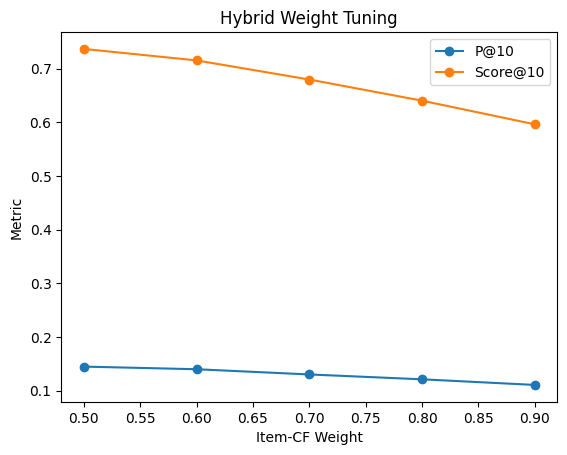

In [ ]:
tune_df.plot(x='W_ITEM', y=['P@10','Score@10'], marker='o', title='Hybrid Weight Tuning')
plt.xlabel('Item-CF Weight')
plt.ylabel('Metric')
plt.show()


### 7.2 Weight Tuning on Train and Test Set

### Purpose
To confirm that the optimized hybrid weights generalize well beyond the training data.  
We evaluate the tuned weights on both the **Train (Leave-One-Out)** set and the **Test** set.

### Approach
- Apply the selected weight combination on:
  - **Train LOO split** (each user leaves one item out).  
  - **Held-out Test set** (future transactions).  
- Compute classic and dual metrics for both datasets.  
- Compare differences to assess overfitting or generalization.

### Key Outputs
- Side-by-side metric tables: Train vs Test.  
- Generalization gap summary (Δ Precision, Δ Recall, Δ Score).
- **Trend plots** showing how performance changes with weighting.  
- **Best weights (W_ITEM, W_USER)** achieving the highest Score@K.
- Saved JSON report: `/outputs/metrics_hybrid_train_vs_test.json`.

### Interpretation
- Small performance gap ⇒ stable, generalizable hybrid model.  
- Large gap ⇒ potential overfitting to training preferences — requires re-tuning or regularization.


In [ ]:
# ============ Weight tuning on both splits (Full 0.1–0.9 sweep) ============
W_ITEM_LIST = np.round(np.linspace(0.1, 0.9, 9), 1)  # [0.1, 0.2, ..., 0.9]
W_USER_LIST = 1.0 - W_ITEM_LIST
K_LIST = [5, 10, 20]
K_PICK = 10
LAM = 0.5
RISK_ADJ = True

print("Running hybrid tuning for W_ITEM in [0.1, 0.9] (9 configs total)\n")

def make_hybrid_scorer(w_item, w_user):
    def _scorer(u):
        s_item = _minmax_safe(scores_itemcf(u))
        s_user = _minmax_safe(
            scores_usercf_weighted(u) if 'scores_usercf_weighted' in globals() else scores_usercf(u)
        )
        s = w_item * s_item + w_user * s_user
        # Optional gentle priors
        s = s + BETA_PROFIT * profit_norm - GAMMA_RISK * risk_norm
        return s
    return _scorer

rows = []
for wi, wu in zip(W_ITEM_LIST, W_USER_LIST):
    scorer = make_hybrid_scorer(wi, wu)

    # Classic metrics
    tr_cls = eval_classic_split(scorer, split="train", k_list=K_LIST)
    te_cls = eval_classic_split(scorer, split="test",  k_list=K_LIST)

    # Dual metrics (preference + profit)
    tr_dual = eval_dual_split(scorer, split="train", k_list=[K_PICK], lam=LAM, risk_adj=RISK_ADJ)
    te_dual = eval_dual_split(scorer, split="test",  k_list=[K_PICK], lam=LAM, risk_adj=RISK_ADJ)

    rows.append({
        'W_ITEM': wi, 'W_USER': wu,
        # Classic Train
        'Train P@10': tr_cls.loc[10,'P'], 'Train R@10': tr_cls.loc[10,'R'], 'Train HR@10': tr_cls.loc[10,'HR'],
        # Classic Test
        'Test P@10':  te_cls.loc[10,'P'], 'Test R@10':  te_cls.loc[10,'R'], 'Test HR@10':  te_cls.loc[10,'HR'],
        # Dual Train
        'Train Pref@10':  tr_dual.loc[K_PICK,'Pref'], 'Train Profit@10': tr_dual.loc[K_PICK,'Profit'], 'Train Score@10': tr_dual.loc[K_PICK,'Score'],
        # Dual Test
        'Test Pref@10':   te_dual.loc[K_PICK,'Pref'], 'Test Profit@10':  te_dual.loc[K_PICK,'Profit'], 'Test Score@10':  te_dual.loc[K_PICK,'Score'],
    })

# Collect & display results
tune_both = pd.DataFrame(rows).sort_values('Test P@10', ascending=False).reset_index(drop=True)
# Choose what to sort by for each split
TARGET_TRAIN = 'Train P@10'      # or 'Train Score@10'
TARGET_TEST  = 'Test P@10'       # or 'Test Score@10'

train_cols = [
    'W_ITEM','W_USER',
    'Train P@10','Train R@10','Train HR@10',
    'Train Pref@10','Train Profit@10','Train Score@10'
]
test_cols = [
    'W_ITEM','W_USER',
    'Test P@10','Test R@10','Test HR@10',
    'Test Pref@10','Test Profit@10','Test Score@10'
]

train_tbl = tune_both[train_cols].sort_values(TARGET_TRAIN, ascending=False).reset_index(drop=True)
test_tbl  = tune_both[test_cols ].sort_values(TARGET_TEST,  ascending=False).reset_index(drop=True)

print("Hybrid weight tuning — TRAIN-LOO (sorted)")
display(train_tbl)
print("Hybrid weight tuning — TEST (sorted)")
display(test_tbl)



Running hybrid tuning for W_ITEM in [0.1, 0.9] (9 configs total)

Hybrid weight tuning — TRAIN-LOO (sorted)


,W_ITEM,W_USER,Train P@10,Train R@10,Train HR@10,Train Pref@10,Train Profit@10,Train Score@10
0,0.2,0.8,0.069733,0.375336,0.587397,0.439198,0.548606,0.493902
1,0.3,0.7,0.069135,0.372597,0.581877,0.442826,0.565308,0.504067
2,0.4,0.6,0.068629,0.372520,0.580957,0.444868,0.561493,0.503181
3,0.5,0.5,0.067985,0.367849,0.576357,0.444797,0.553245,0.499021
4,0.1,0.9,0.067479,0.366038,0.575437,0.428133,0.535054,0.481593
5,0.6,0.4,0.065087,0.348385,0.553818,0.443459,0.530909,0.487184
6,0.7,0.3,0.058878,0.293819,0.496320,0.436858,0.470179,0.453519
7,0.8,0.2,0.054692,0.264828,0.459982,0.434825,0.430648,0.432736
8,0.9,0.1,0.049632,0.227939,0.414903,0.431899,0.349820,0.390860


Hybrid weight tuning — TEST (sorted)


,W_ITEM,W_USER,Test P@10,Test R@10,Test HR@10,Test Pref@10,Test Profit@10,Test Score@10
0,0.2,0.8,0.151242,0.646873,0.802668,0.560158,0.949369,0.754763
1,0.1,0.9,0.150874,0.642120,0.796688,0.553290,0.926395,0.739843
2,0.3,0.7,0.149034,0.638370,0.795768,0.560483,0.936727,0.748605
3,0.4,0.6,0.147608,0.633115,0.793008,0.558468,0.938690,0.748579
4,0.5,0.5,0.145032,0.622185,0.786109,0.553873,0.919694,0.736783
5,0.6,0.4,0.140110,0.592338,0.756670,0.547573,0.883218,0.715396
6,0.7,0.3,0.130405,0.522719,0.690432,0.534867,0.824667,0.679767
7,0.8,0.2,0.121343,0.467188,0.637534,0.524436,0.756393,0.640414
8,0.9,0.1,0.110902,0.408278,0.582797,0.512924,0.679788,0.596356


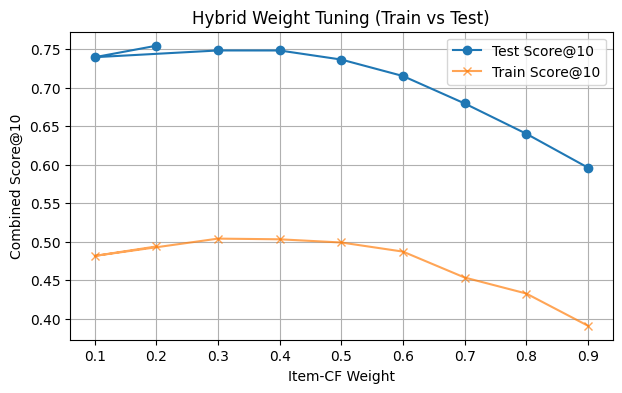

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(tune_both['W_ITEM'], tune_both['Test Score@10'], marker='o', label='Test Score@10')
plt.plot(tune_both['W_ITEM'], tune_both['Train Score@10'], marker='x', label='Train Score@10', alpha=0.7)
plt.xlabel("Item-CF Weight")
plt.ylabel("Combined Score@10")
plt.title("Hybrid Weight Tuning (Train vs Test)")
plt.legend()
plt.grid(True)
plt.show()


## 7.3) Ablation Test

### 7.3 Ablation Test

### Purpose
To quantify the individual contribution of **User-CF**, **Item-CF**, and the **Hybrid** combination.  
By systematically removing one component, we verify its impact on overall performance.

### Approach
Evaluate and compare the following configurations:
1. **Item-CF Only** (`W_ITEM = 1.0, W_USER = 0.0`)  
2. **User-CF Only** (`W_ITEM = 0.0, W_USER = 1.0`)  
3. **Hybrid Model** (`W_ITEM = W_ITEM*, W_USER = W_USER*` from tuning)

Compute Precision@K, Recall@K, Hit-Rate@K, and Score@K for each setup.  
Plot a grouped bar chart comparing results.

### Key Outputs
- **Ablation table** summarizing metrics for each model variant.  
- **Performance comparison plot** (Item-CF vs User-CF vs Hybrid).  
- Saved file: `/outputs/ablation_results.json` or `/outputs/ablation_plot.png`.

### Interpretation
- If Hybrid ≫ Item-CF and User-CF ⇒ both components add unique value.  
- If Hybrid ≈ one component ⇒ the other adds little information.  
This experiment validates that the hybridization genuinely enhances predictive power and is not redundant.


In [ ]:
# ===================== ABLATION STUDY =====================
import numpy as np
import pandas as pd

# ---- Baseline/tuned hyperparams (adjust to your best) ----
BEST_W_ITEM, BEST_W_USER = 0.2, 0.8
# default priors you currently use in hybrid
BETA_PROFIT_DEF = 0.05
GAMMA_RISK_DEF  = 0.05
ETA_PREF_DEF    = 0.10  # if you added pref boost in scoring
MU_PROFIT_DEF   = 0.05  # if you added extra profit boost in scoring
USE_WEIGHTED_USER = 'scores_usercf_weighted' in globals()

def _user_scores(u):
    return (scores_usercf_weighted(u) if USE_WEIGHTED_USER else scores_usercf(u))

def make_ablation_scorer(w_item, w_user, beta_profit, gamma_risk, eta_pref=0.0, mu_profit=0.0):
    """Build a scorer with togglable priors/boosts."""
    def _scorer(u):
        s_item = _minmax_safe(scores_itemcf(u))
        s_user = _minmax_safe(_user_scores(u))
        s = w_item * s_item + w_user * s_user
        # content priors
        if beta_profit != 0:
            s = s + beta_profit * profit_norm
        if gamma_risk != 0:
            s = s - gamma_risk * risk_norm
        # optional shaping
        if eta_pref != 0:
            s = s + eta_pref * _minmax_safe(pref_scores(u))
        if mu_profit != 0:
            s = s + mu_profit * profit_norm
        return s
    return _scorer

# ---- Define ablations ----
ablations = [
    {"name": "Item-CF only",            "w_item": 1.0, "w_user": 0.0, "bp":0.0, "gr":0.0, "ep":0.0, "mp":0.0},
    {"name": "User-CF only",            "w_item": 0.0, "w_user": 1.0, "bp":0.0, "gr":0.0, "ep":0.0, "mp":0.0},
    {"name": "Hybrid tuned",            "w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":BETA_PROFIT_DEF, "gr":GAMMA_RISK_DEF, "ep":0.0, "mp":0.0},
    {"name": "Hybrid (no profit prior)","w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":0.0, "gr":GAMMA_RISK_DEF, "ep":0.0, "mp":0.0},
    {"name": "Hybrid (no risk prior)",  "w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":BETA_PROFIT_DEF, "gr":0.0, "ep":0.0, "mp":0.0},
    {"name": "Hybrid (no priors)",      "w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":0.0, "gr":0.0, "ep":0.0, "mp":0.0},
    {"name": "Hybrid + pref boost",     "w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":BETA_PROFIT_DEF, "gr":GAMMA_RISK_DEF, "ep":ETA_PREF_DEF, "mp":0.0},
    {"name": "Hybrid + profit boost",   "w_item": BEST_W_ITEM, "w_user": BEST_W_USER, "bp":BETA_PROFIT_DEF, "gr":GAMMA_RISK_DEF, "ep":0.0, "mp":MU_PROFIT_DEF},
]

K_LIST = [5,10,20]
K_PICK = 10
LAM = 0.5
RISK_ADJ = True

rows = []
for cfg in ablations:
    scorer = make_ablation_scorer(cfg["w_item"], cfg["w_user"], cfg["bp"], cfg["gr"], cfg["ep"], cfg["mp"])
    # classic
    tr = eval_classic_split(scorer, split="train", k_list=K_LIST)
    te = eval_classic_split(scorer, split="test",  k_list=K_LIST)
    # dual
    trd = eval_dual_split(scorer, split="train", k_list=[K_PICK], lam=LAM, risk_adj=RISK_ADJ)
    ted = eval_dual_split(scorer, split="test",  k_list=[K_PICK], lam=LAM, risk_adj=RISK_ADJ)
    rows.append({
        "Model": cfg["name"],
        # Train classic
        "Train P@10": tr.loc[10,"P"], "Train R@10": tr.loc[10,"R"], "Train HR@10": tr.loc[10,"HR"],
        # Test classic
        "Test P@10":  te.loc[10,"P"], "Test R@10":  te.loc[10,"R"], "Test HR@10":  te.loc[10,"HR"],
        # Train dual
        "Train Pref@10": trd.loc[K_PICK,"Pref"], "Train Profit@10": trd.loc[K_PICK,"Profit"], "Train Score@10": trd.loc[K_PICK,"Score"],
        # Test dual
        "Test Pref@10":  ted.loc[K_PICK,"Pref"], "Test Profit@10":  ted.loc[K_PICK,"Profit"], "Test Score@10":  ted.loc[K_PICK,"Score"],
    })

abl_df = pd.DataFrame(rows)

# Present as two clean tables (Train first, then Test)
train_tbl = abl_df[["Model","Train P@10","Train R@10","Train HR@10","Train Pref@10","Train Profit@10","Train Score@10"]] \
            .sort_values("Train P@10", ascending=False).reset_index(drop=True)
test_tbl  = abl_df[["Model","Test P@10","Test R@10","Test HR@10","Test Pref@10","Test Profit@10","Test Score@10"]] \
            .sort_values("Test P@10",  ascending=False).reset_index(drop=True)

print("Ablation — TRAIN-LOO (sorted by P@10)")
display(train_tbl)
print("Ablation — TEST (sorted by P@10)")
display(test_tbl)


Ablation — TRAIN-LOO (sorted by P@10)


,Model,Train P@10,Train R@10,Train HR@10,Train Pref@10,Train Profit@10,Train Score@10
0,Hybrid (no profit prior),0.070147,0.377919,0.588316,0.439036,0.558801,0.498919
1,Hybrid (no priors),0.069871,0.379288,0.590616,0.475207,0.569855,0.522531
2,Hybrid tuned,0.069733,0.375336,0.587397,0.439198,0.548606,0.493902
3,Hybrid + pref boost,0.068123,0.369082,0.580037,0.580522,0.554145,0.567333
4,Hybrid (no risk prior),0.067985,0.369610,0.577277,0.477285,0.575091,0.526188
5,User-CF only,0.066743,0.357169,0.569457,0.474887,0.571114,0.523000
6,Hybrid + profit boost,0.065087,0.353043,0.555198,0.437909,0.538820,0.488364
7,Item-CF only,0.047608,0.215087,0.395584,0.443648,0.351192,0.397420


Ablation — TEST (sorted by P@10)


,Model,Test P@10,Test R@10,Test HR@10,Test Pref@10,Test Profit@10,Test Score@10
0,User-CF only,0.153036,0.645492,0.792088,0.590999,0.898592,0.744796
1,Hybrid (no profit prior),0.152714,0.652565,0.805428,0.563151,0.945653,0.754402
2,Hybrid (no priors),0.151656,0.653366,0.807728,0.590409,0.944171,0.767290
3,Hybrid tuned,0.151242,0.646873,0.802668,0.560158,0.949369,0.754763
4,Hybrid + pref boost,0.151196,0.646894,0.803128,0.669085,0.947093,0.808089
5,Hybrid (no risk prior),0.150782,0.646306,0.802668,0.588558,0.945746,0.767152
6,Hybrid + profit boost,0.147194,0.623943,0.785649,0.554516,0.939063,0.746790
7,Item-CF only,0.101932,0.374027,0.553818,0.517572,0.632465,0.575018
